In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv("/content/updated1_eng_data.csv")
data

,year,engine,mileage,transmission,model_code,fuel,color,steering,drive_type,seats,doors,stock_id,location,price,Year,Brand,Title,body_type
0,2018/07,5120.0,304000 km,AT,2DG-HX9JHCE,Diesel,White,RHD,2WD,24,1,sat-95017853,Saitama,"$61,066",2018,Hino,Poncho Short Route Bus 24 Passengers 14 Seats,bus
1,2019/08,5190.0,153142 km,AT,2RG-FTR90V2,Diesel,White,Not Set,2WD,2,2,sat-45474888,Niigata,"$61,066",2019,Isuzu,Forward Cargo Crane,crane
2,2024/07,7540.0,1000 km,MT,2KG-FK62FZ,Diesel,White,Not Set,4wd,2,2,sat-41226194,Aichi,"$61,066",2024,Mitsubishi,Fighter Arm Roll,truck
3,2021/09,5120.0,226000 km,MT,2PG-FE2ABG,Diesel,Black,Not Set,2WD,2,2,sat-90350899,Aichi,"$61,066",2021,Hino,Ranger Wing Truck,truck
4,2023/05,5120.0,1000 km,MT,2PG-FD2ABA,Diesel,Grey,Not Set,2WD,2,2,sat-84703524,Osaka,"$61,066",2023,Hino,Ranger Wing Truck,truck
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2824,2023/08,2500.0,16 km,AT,6AA-AAHH45W,Hybrid,Blue,RHD,4WD(AWD),7,5,sat-18263293,Wakayama,"$74,106",2023,Toyota,Alphard Hybrid 4wd Executive Lounge,minivan
2825,2023/01,5000.0,7720 km,AT,5BA-URZ100,Petrol,Pearl,RHD,2WD,4,2,sat-52026539,Tokyo,"$74,106",2023,Lexus,Lc 500 Base Grade,Hatchback
2826,2021/03,4400.0,3300 km,AT,3BA-JU44M,Petrol,Red,RHD,4WD(AWD),5,5,sat-98825242,Hyogo,"$74,341",2021,Bmw,X6 M Competition,sportscar
2827,2022/12,3500.0,5048 km,AT,3BA-VJA300W,Petrol,Pearl,RHD,4WD(AWD),7,5,sat-17609474,Gifu,"$74,347",2022,Toyota,Land Cruiser Wagon Zx ?with Modellista Aero Parts,suv


In [ ]:
for col in data.columns:
    print(f"Value counts for column '{col}':")
    print(data[col].value_counts())
    print("-" * 20)

Value counts for column 'year':
year
2023/11    93
2023/09    90
2023/10    87
2024/03    80
2024/06    78
           ..
1995/08     1
1974/04     1
2008/11     1
2008/02     1
2020        1
Name: count, Length: 205, dtype: int64
--------------------
Value counts for column 'engine':
engine
3000.0    478
7540.0    407
2000.0    218
2500.0    190
4000.0    172
         ... 
9999.0      1
2480.0      1
2600.0      1
235.0       1
2393.0      1
Name: count, Length: 86, dtype: int64
--------------------
Value counts for column 'mileage':
mileage
1000 km     321
2000 km      50
10 km        15
4000 km      14
25000 km     12
           ... 
45934 km      1
4111 km       1
45933 km      1
8783 km       1
30 km         1
Name: count, Length: 1338, dtype: int64
--------------------
Value counts for column 'transmission':
transmission
AT    1553
MT    1202
Name: count, dtype: int64
--------------------
Value counts for column 'model_code':
model_code
2KG-FK62FZ     319
6AA-AAHH40W     46
3BA-VJ

In [ ]:


# Define column order
column_order = [
    "stock_id", "model_code", "Title",  # Identifiers
    "Brand", "Year", "engine", "fuel", "transmission", "body_type",  # Attributes
    "mileage", "color", "steering", "drive_type", "seats", "doors",  # Specifications
    "price", "location"  # Price and Location
]

# Convert 'Year' to integer
data["Year"] = pd.to_numeric(data["Year"], errors="coerce")

# Convert 'engine' to float
data["engine"] = pd.to_numeric(data["engine"], errors="coerce")

# Clean and convert 'mileage' to integer (remove 'km' and commas)
data["mileage"] = data["mileage"].str.replace(" km", "").str.replace(",", "").astype(int)

# Convert 'transmission' to category
data["transmission"] = data["transmission"].astype("category")

# Convert 'seats' and 'doors' to integer
data["seats"] = pd.to_numeric(data["seats"], errors="coerce")
data["doors"] = pd.to_numeric(data["doors"], errors="coerce")

# Clean and convert 'price' to integer (remove '$' and commas)
data["price"] = data["price"].str.replace("$", "").str.replace(",", "").astype(int)

# Drop duplicate 'Year' column if it exists
if "year" in data.columns:
    data = data.drop(columns=["year"])

# Convert categorical columns to 'category' type
categorical_columns = ["fuel", "color", "steering", "drive_type", "model_code", "location", "Brand", "Title", "body_type"]
data[categorical_columns] = data[categorical_columns].astype("category")

# Reorder the columns
data = data[column_order]

# Randomly select 10% of rows where body_type is 'COUPE'
rows_to_change = data[data['body_type'] == 'COUPE'].sample(frac=0.1, random_state=42).index

# Change the body_type of those rows to 'SEDAN'
data.loc[rows_to_change, 'body_type'] = 'SEDAN'

# Add 'BUS' to the categories of the 'body_type' column
data['body_type'] = pd.Categorical(data['body_type'], categories=data['body_type'].cat.categories.union(['BUS']))

# Set 'body_type' to 'BUS' where 'seats' > 20
data.loc[data['seats'] > 20, 'body_type'] = 'BUS'

# Convert 'body_type' values to uppercase
data['body_type'] = data['body_type'].str.upper()

# Replace 'SPORTS' with 'SPORTS CARS' in the 'body_type' column
data['body_type'] = data['body_type'].replace('SPORTS', 'SPORTS CARS')

# Change number of doors to 4 where seats are 40 or greater
data.loc[data['seats'] >= 40, 'doors'] = 4

# Remove duplicate rows
data_no_duplicates = data.drop_duplicates()

# Remove rows with missing values
data_no_duplicates.dropna(inplace=True)

# Convert 'drive_type' to uppercase
data_no_duplicates['drive_type'] = data_no_duplicates['drive_type'].str.upper()

# Replace '4WD(AWD)' with '4WD' in the 'drive_type' column
data_no_duplicates['drive_type'] = data_no_duplicates['drive_type'].replace('4WD(AWD)', '4WD')

# Save the updated data to a new file
data_no_duplicates.to_csv('updated_data.csv', index=False)

# Optionally, print the final info to verify
data_no_duplicates.info()



<class 'pandas.core.frame.DataFrame'>
Index: 2598 entries, 0 to 2828
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   stock_id      2598 non-null   object  
 1   model_code    2598 non-null   category
 2   Title         2598 non-null   category
 3   Brand         2598 non-null   category
 4   Year          2598 non-null   float64 
 5   engine        2598 non-null   float64 
 6   fuel          2598 non-null   category
 7   transmission  2598 non-null   category
 8   body_type     2598 non-null   object  
 9   mileage       2598 non-null   int64   
 10  color         2598 non-null   category
 11  steering      2598 non-null   category
 12  drive_type    2598 non-null   object  
 13  seats         2598 non-null   float64 
 14  doors         2598 non-null   float64 
 15  price         2598 non-null   int64   
 16  location      2598 non-null   category
dtypes: category(8), float64(4), int64(2), object(3)
memory us

In [ ]:
for col in data.columns:
    print(f"Value counts for column '{col}':")
    print(data[col].value_counts())
    print("-" * 20)

Value counts for column 'stock_id':
stock_id
sat-97841122    2
sat-90773658    2
sat-87000602    2
sat-55172040    2
sat-63794907    2
               ..
sat-31789728    1
sat-26269821    1
sat-22826260    1
sat-89258869    1
sat-97491820    1
Name: count, Length: 2328, dtype: int64
--------------------
Value counts for column 'model_code':
model_code
2KG-FK62FZ     319
6AA-AAHH40W     46
3BA-VJA300W     40
2KG-FK65F       35
2PG-CYJ77C      33
              ... 
ZAA-295153       1
-1FATP42         1
daa-222158       1
urj201           1
xzb70            1
Name: count, Length: 553, dtype: int64
--------------------
Value counts for column 'Title':
Title
Fighter Cargo Crane                       129
Fighter Arm Roll                           86
Fighter Dump Truck                         60
Fighter Crane With Loader                  47
Ranger Wing Truck                          46
                                         ... 
Fuso Super Great Premium Line               1
Fuso Super Great 

In [ ]:


# Set 'body_type' to 'BUS' where 'seats' > 20
data.loc[data['seats'] > 20, 'body_type'] = 'BUS'


In [ ]:
data_no_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2598 entries, 0 to 2828
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   stock_id      2598 non-null   object  
 1   model_code    2598 non-null   category
 2   Title         2598 non-null   category
 3   Brand         2598 non-null   category
 4   Year          2598 non-null   float64 
 5   engine        2598 non-null   float64 
 6   fuel          2598 non-null   category
 7   transmission  2598 non-null   category
 8   body_type     2598 non-null   object  
 9   mileage       2598 non-null   int64   
 10  color         2598 non-null   category
 11  steering      2598 non-null   category
 12  drive_type    2598 non-null   object  
 13  seats         2598 non-null   float64 
 14  doors         2598 non-null   float64 
 15  price         2598 non-null   int64   
 16  location      2598 non-null   category
dtypes: category(8), float64(4), int64(2), object(3)
memory us

In [ ]:
data_no_duplicates.describe()

,Year,engine,mileage,seats,doors,price
count,2598.000000,2598.000000,2598.00000,2598.000000,2598.000000,2598.000000
mean,2020.343726,4653.749423,63428.56582,4.219784,3.222479,52485.130100
std,5.341191,2865.960663,144953.20354,3.973706,1.356881,10565.479554
min,1973.000000,45.000000,4.00000,2.000000,1.000000,40021.000000
25%,2019.000000,2990.000000,1030.00000,2.000000,2.000000,42688.000000
50%,2022.000000,3500.000000,9695.50000,4.000000,2.000000,49616.000000
75%,2023.000000,6925.000000,35816.00000,5.000000,5.000000,61702.000000
max,2024.000000,21200.000000,1000000.00000,56.000000,5.000000,74360.000000


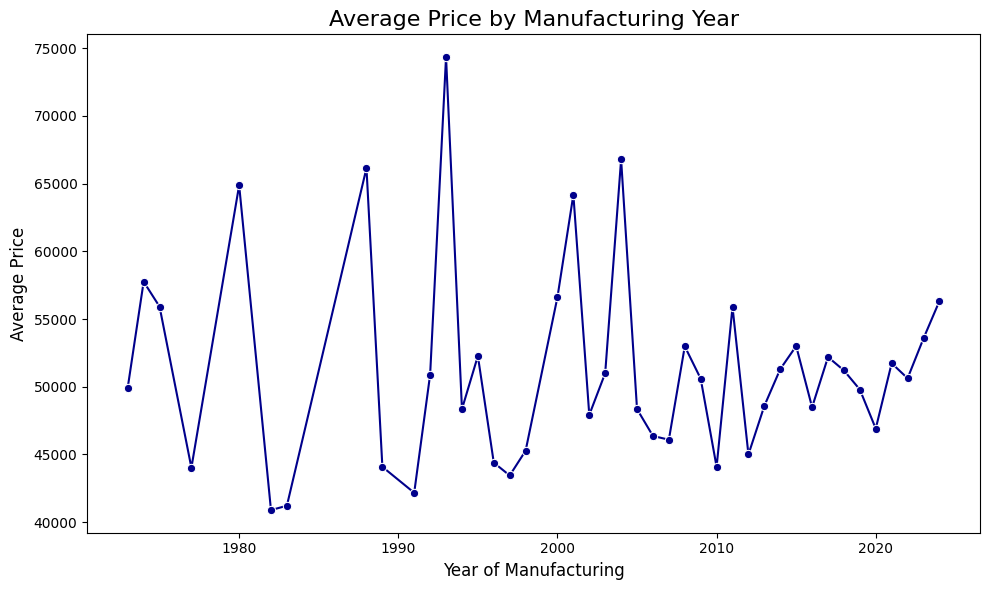

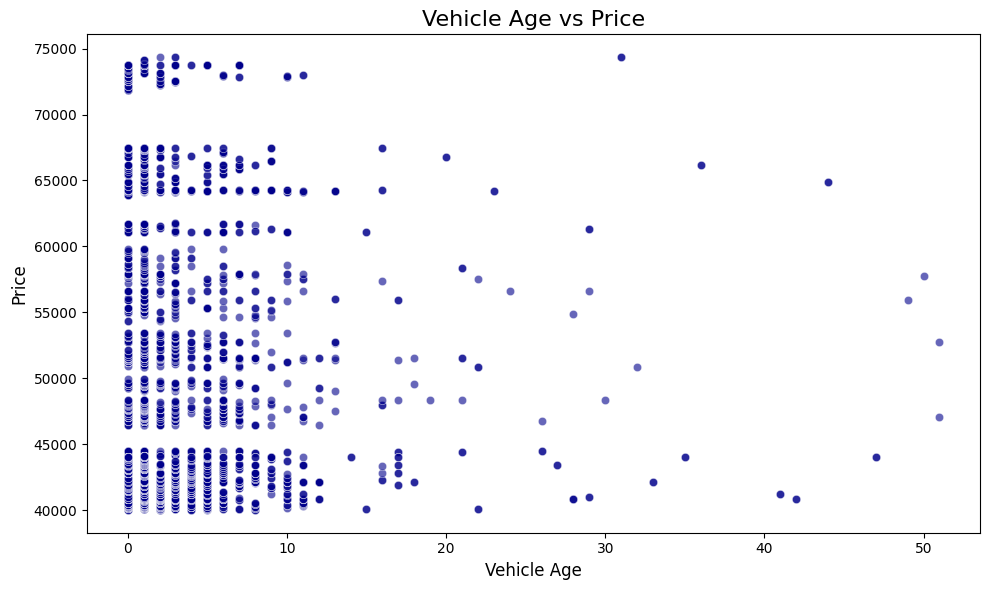

In [ ]:


# Assuming data_no_duplicates is already defined and processed as in your code.

# 2. Average Price of Vehicles Grouped by Year of Manufacturing
plt.figure(figsize=(10, 6))
avg_price_by_year = data_no_duplicates.groupby('Year')['price'].mean().reset_index()
sns.lineplot(x='Year', y='price', data=avg_price_by_year, marker='o', color='darkblue')
plt.title('Average Price by Manufacturing Year', fontsize=16)
plt.xlabel('Year of Manufacturing', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Impact of Vehicle Age on Price Trends
data_no_duplicates['age'] = 2024 - data_no_duplicates['Year']  # Assuming current year is 2024
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='price', data=data_no_duplicates, color='darkblue', alpha=0.6)
plt.title('Vehicle Age vs Price', fontsize=16)
plt.xlabel('Vehicle Age', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.tight_layout()
plt.show()

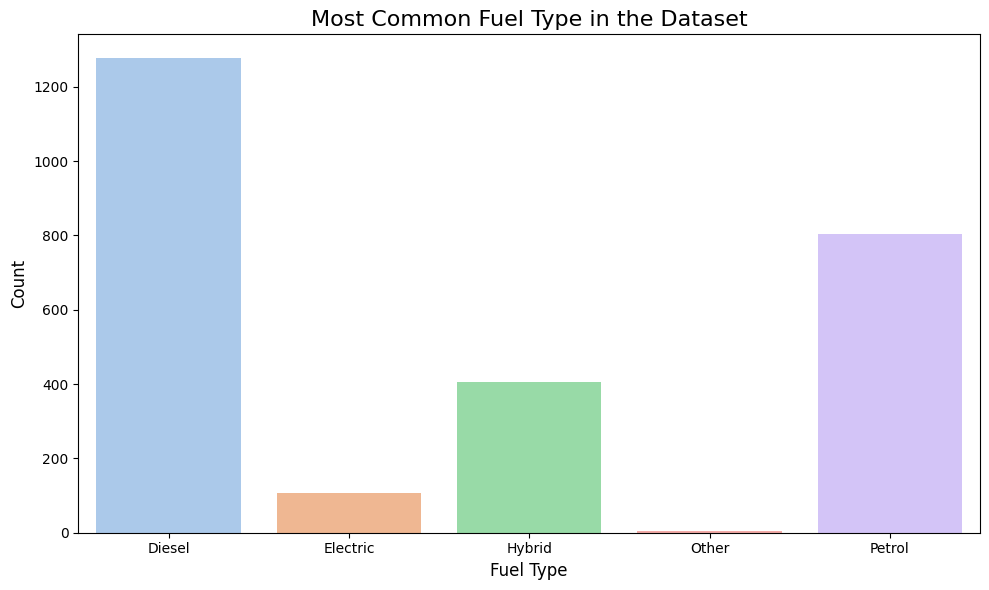

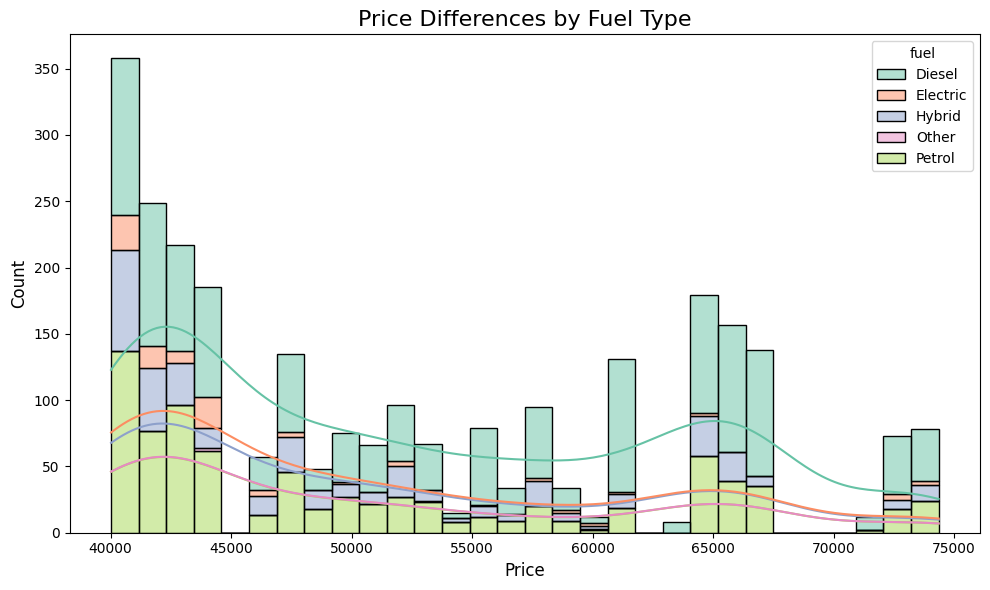

In [ ]:
# prompt: # 2. Most Common Fuel Type in the Dataset
# plt.figure(figsize=(10, 6))
# fuel_counts = data['fuel'].value_counts().reset_index()
# fuel_counts.columns = ['Fuel Type', 'Count']
# sns.barplot(x='Fuel Type', y='Count', data=fuel_counts, palette="pastel")
# plt.title('Most Common Fuel Type in the Dataset', fontsize=16)
# plt.xlabel('Fuel Type', fontsize=12)
# plt.ylabel('Count', fontsize=12)
# plt.tight_layout()
# plt.show()
# # 3. Price Differences Between Vehicles with Petrol, Diesel, or Electric Engines (Histogram)
# plt.figure(figsize=(10, 6))
# sns.histplot(data=data, x='price', hue='fuel', kde=True, multiple='stack', palette="Set2", bins=30)
# plt.title('Price Differences by Fuel Type', fontsize=16)
# plt.xlabel('Price', fontsize=12)
# plt.ylabel('Count', fontsize=12)
# plt.tight_layout()
# plt.show()
#  data_no_duplicates generate for this

# Assuming data_no_duplicates is already defined and processed as in your code.

# 2. Most Common Fuel Type in the Dataset
plt.figure(figsize=(10, 6))
fuel_counts = data_no_duplicates['fuel'].value_counts().reset_index()
fuel_counts.columns = ['Fuel Type', 'Count']
sns.barplot(x='Fuel Type', y='Count', data=fuel_counts, palette="pastel")
plt.title('Most Common Fuel Type in the Dataset', fontsize=16)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Price Differences Between Vehicles with Petrol, Diesel, or Electric Engines (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data=data_no_duplicates, x='price', hue='fuel', kde=True, multiple='stack', palette="Set2", bins=30)
plt.title('Price Differences by Fuel Type', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

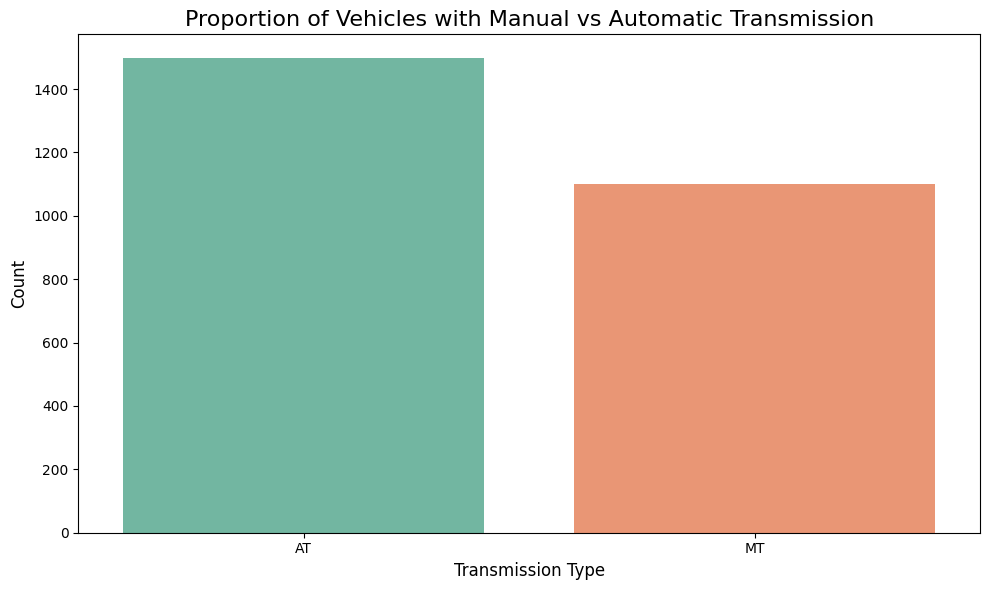

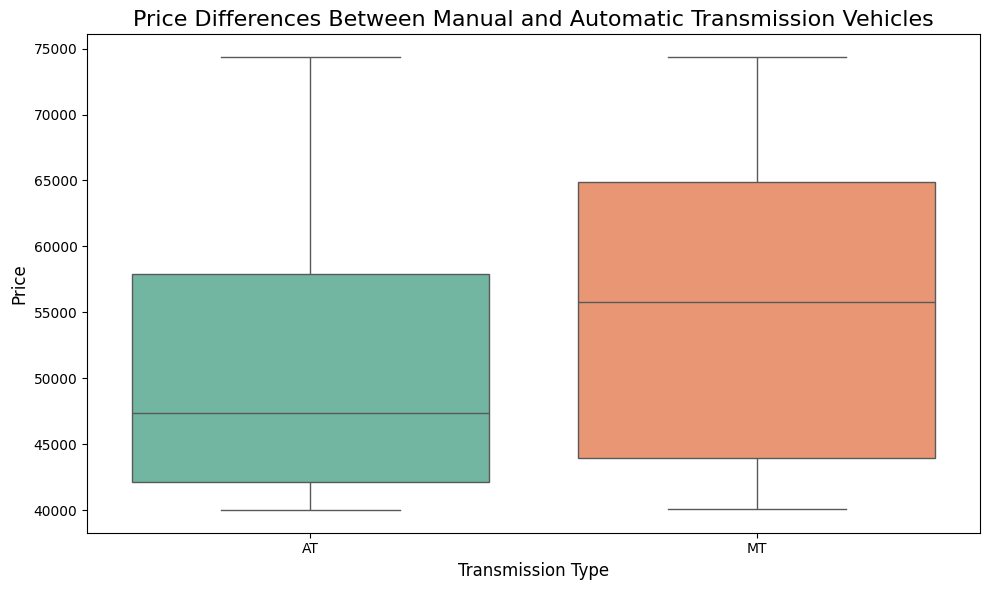

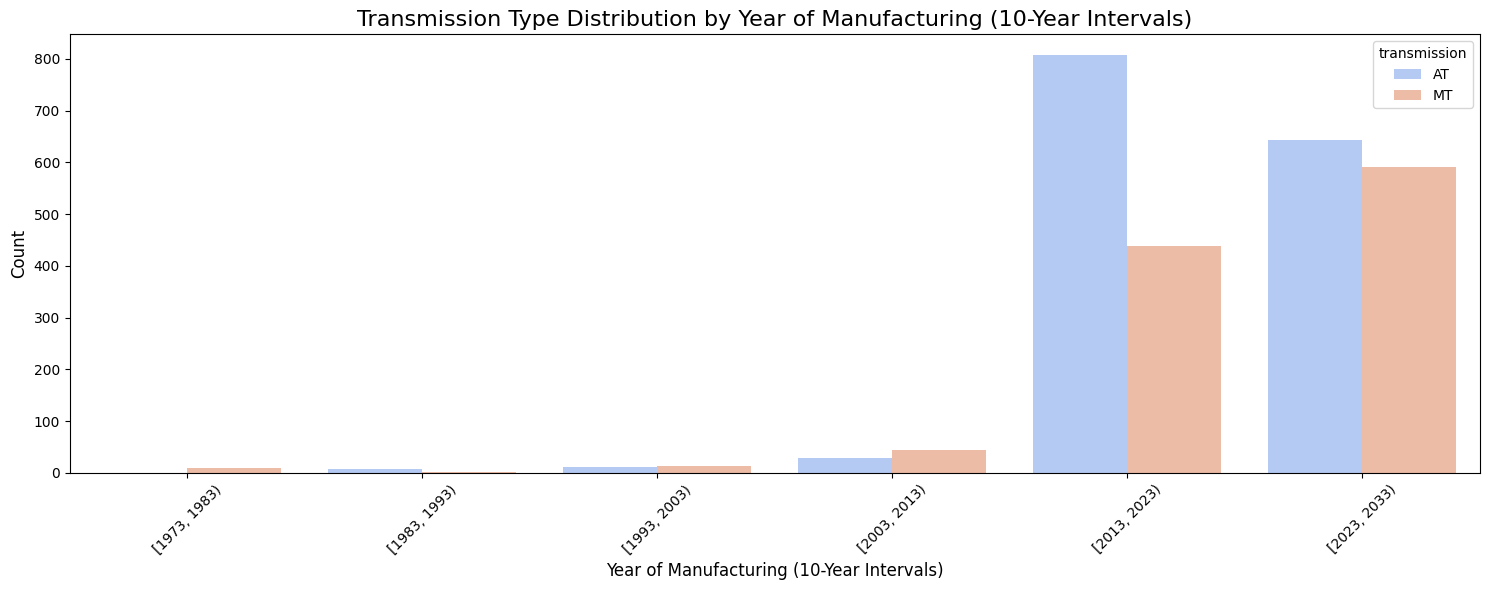

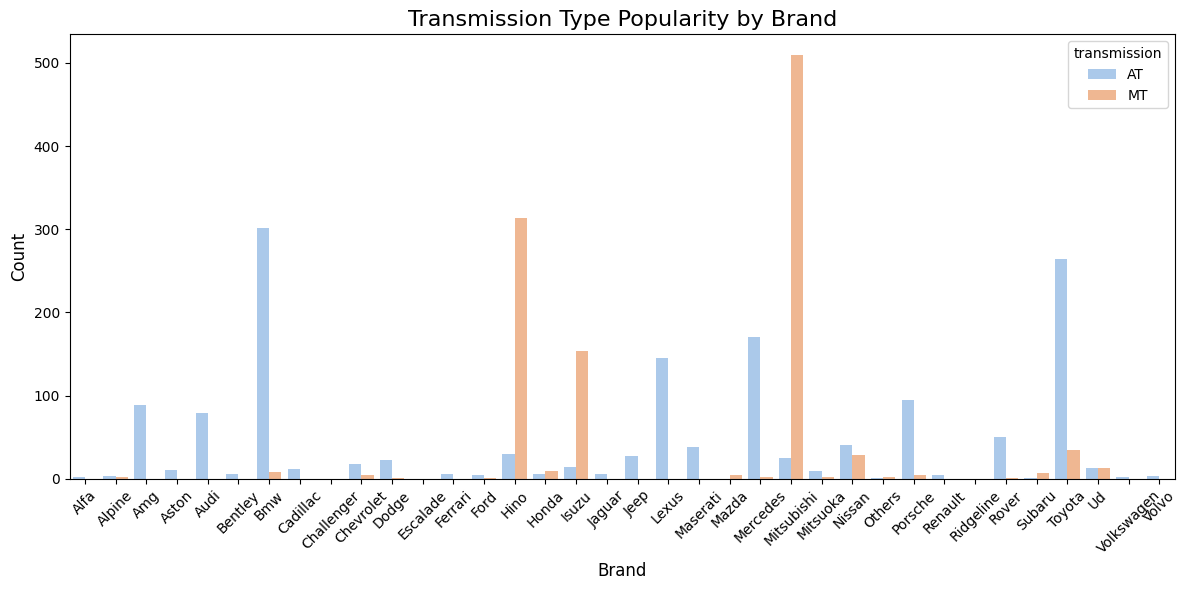

In [ ]:
# prompt: # 1. Proportion of vehicles with manual vs. automatic transmission
# plt.figure(figsize=(10, 6))
# transmission_counts = data['transmission'].value_counts().reset_index()
# transmission_counts.columns = ['Transmission Type', 'Count']
# sns.barplot(x='Transmission Type', y='Count', data=transmission_counts, palette="Set2")
# plt.title('Proportion of Vehicles with Manual vs Automatic Transmission', fontsize=16)
# plt.xlabel('Transmission Type', fontsize=12)
# plt.ylabel('Count', fontsize=12)
# plt.tight_layout()
# plt.show()
# # 2. Price differences between manual and automatic transmission vehicles
# plt.figure(figsize=(10, 6))
# sns.boxplot(x='transmission', y='price', data=data, palette="Set2")
# plt.title('Price Differences Between Manual and Automatic Transmission Vehicles', fontsize=16)
# plt.xlabel('Transmission Type', fontsize=12)
# plt.ylabel('Price', fontsize=12)
# plt.tight_layout()
# plt.show()
# # 3. Distribution of transmission type by year of manufacturing
# plt.figure(figsize=(15, 6))
# sns.countplot(x='Year', hue='transmission', data=data, palette="coolwarm")
# plt.title('Transmission Type Distribution by Year of Manufacturing', fontsize=16)
# plt.xlabel('Year of Manufacturing', fontsize=12)
# plt.ylabel('Count', fontsize=12)
# plt.tight_layout()
# plt.show()
# # 4. Popularity of transmission types by brand
# plt.figure(figsize=(12, 6))
# sns.countplot(x='Brand', hue='transmission', data=data, palette="pastel")
# plt.title('Transmission Type Popularity by Brand', fontsize=16)
# plt.xlabel('Brand', fontsize=12)
# plt.ylabel('Count', fontsize=12)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()data_no_duplicates generate for this
# and change Transmission Type Distribution by Year of Manufacturing in 10 year duration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Your existing code for data loading and preprocessing)

# Assuming data_no_duplicates is already defined and processed

# 1. Proportion of vehicles with manual vs. automatic transmission
plt.figure(figsize=(10, 6))
transmission_counts = data_no_duplicates['transmission'].value_counts().reset_index()
transmission_counts.columns = ['Transmission Type', 'Count']
sns.barplot(x='Transmission Type', y='Count', data=transmission_counts, palette="Set2")
plt.title('Proportion of Vehicles with Manual vs Automatic Transmission', fontsize=16)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Price differences between manual and automatic transmission vehicles
plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission', y='price', data=data_no_duplicates, palette="Set2")
plt.title('Price Differences Between Manual and Automatic Transmission Vehicles', fontsize=16)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Distribution of transmission type by year of manufacturing (10-year duration)
plt.figure(figsize=(15, 6))

# Calculate 10-year bins
# Calculate 10-year bins
data_no_duplicates['YearGroup'] = pd.cut(
    data_no_duplicates['Year'],
    bins=range(int(min(data_no_duplicates['Year'])), int(max(data_no_duplicates['Year'])) + 10, 10),
    right=False
)
sns.countplot(x='YearGroup', hue='transmission', data=data_no_duplicates, palette="coolwarm")
plt.title('Transmission Type Distribution by Year of Manufacturing (10-Year Intervals)', fontsize=16)
plt.xlabel('Year of Manufacturing (10-Year Intervals)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 4. Popularity of transmission types by brand
plt.figure(figsize=(12, 6))
sns.countplot(x='Brand', hue='transmission', data=data_no_duplicates, palette="pastel")
plt.title('Transmission Type Popularity by Brand', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 5 Most Common Brands:
 Brand
Mitsubishi    534
Hino          343
Bmw           310
Toyota        298
Mercedes      172
Name: count, dtype: int64

Price range for Mitsubishi: $40074 - $73788

Price range for Hino: $40074 - $73788

Price range for Bmw: $40053 - $74341

Price range for Toyota: $40068 - $74347

Price range for Mercedes: $40074 - $73788

Average Mileage for Top 10 Brands:
 Brand
Mitsubishi     62572.692884
Hino          145119.740525
Bmw            14341.241935
Toyota         18564.630872
Mercedes       24181.877907
Isuzu         242851.755952
Lexus          20442.655172
Porsche        25330.313131
Amg            17016.550562
Audi           10865.734177
Name: mileage, dtype: float64

Average Engine Size by Brand:
 Brand
Alfa           1300.000000
Alpine         3400.000000
Amg            2853.932584
Aston          5980.000000
Audi           1895.063291
Bentley        6466.666667
Bmw            2551.258065
Cadillac       6200.000000
Challenger             NaN
Chevrolet  

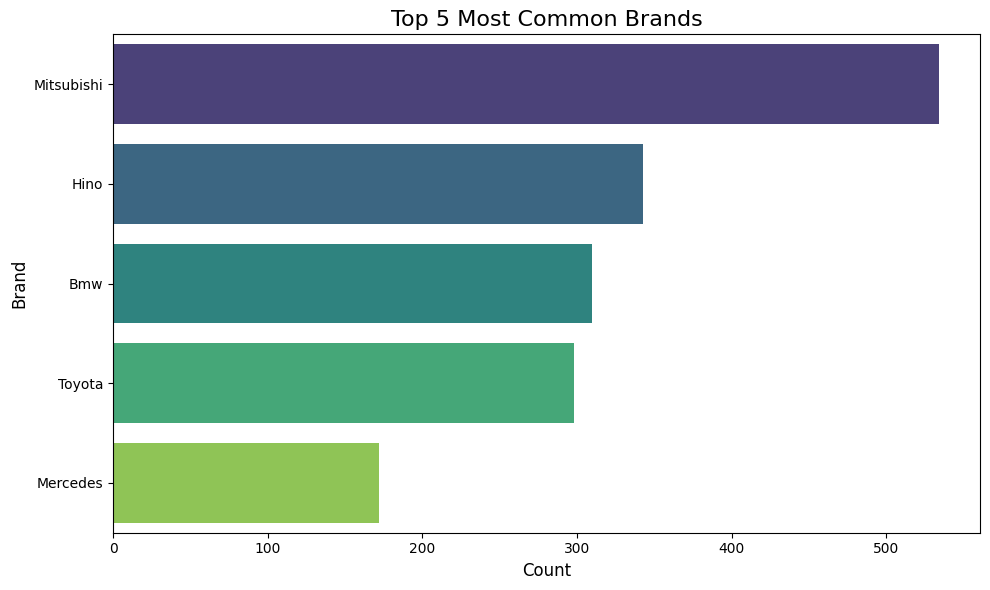

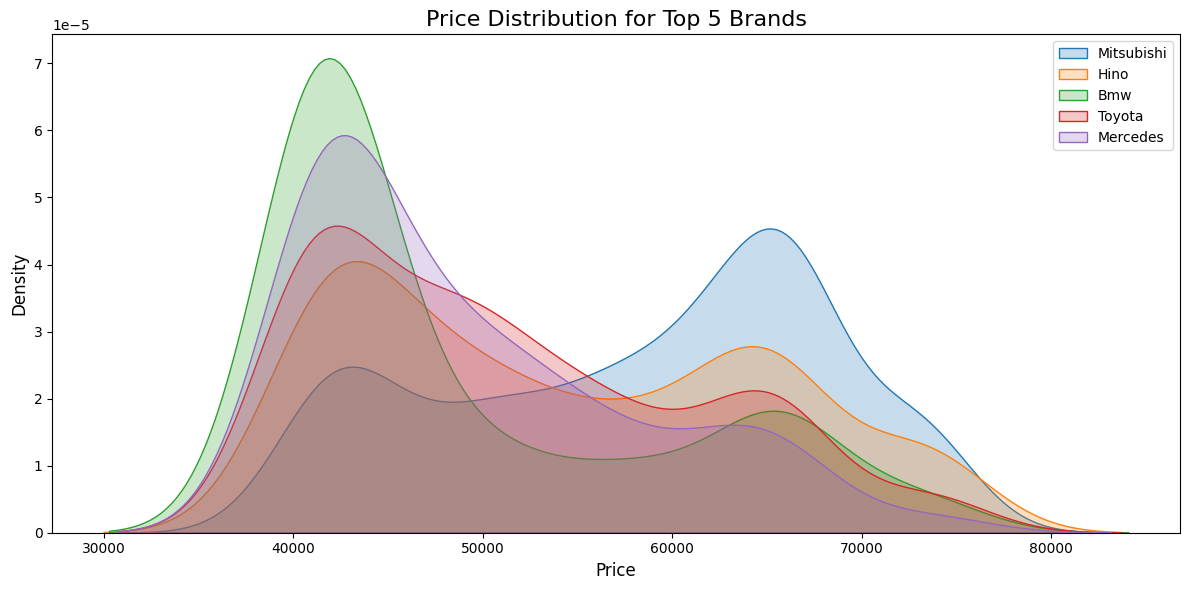

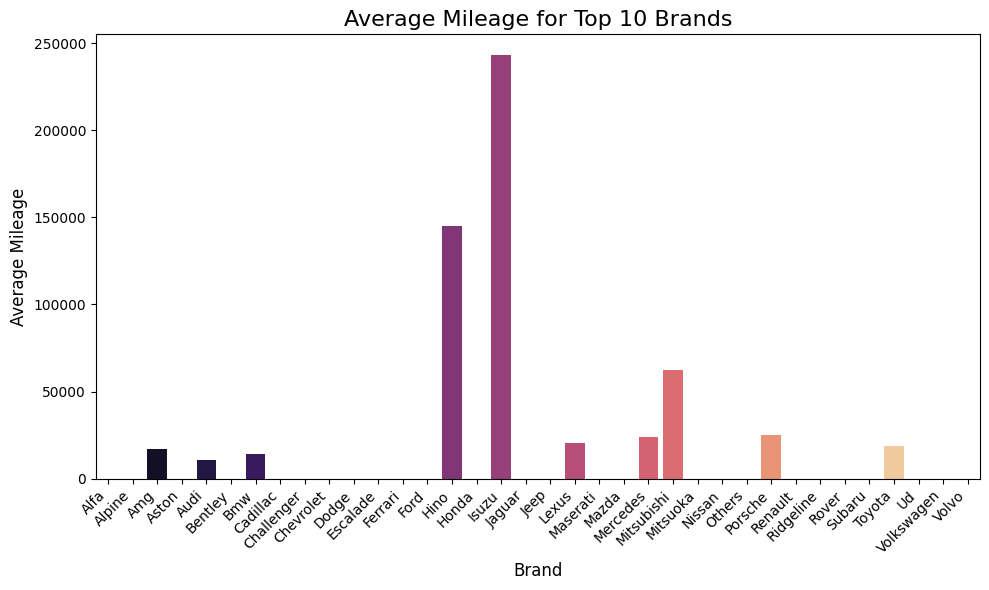

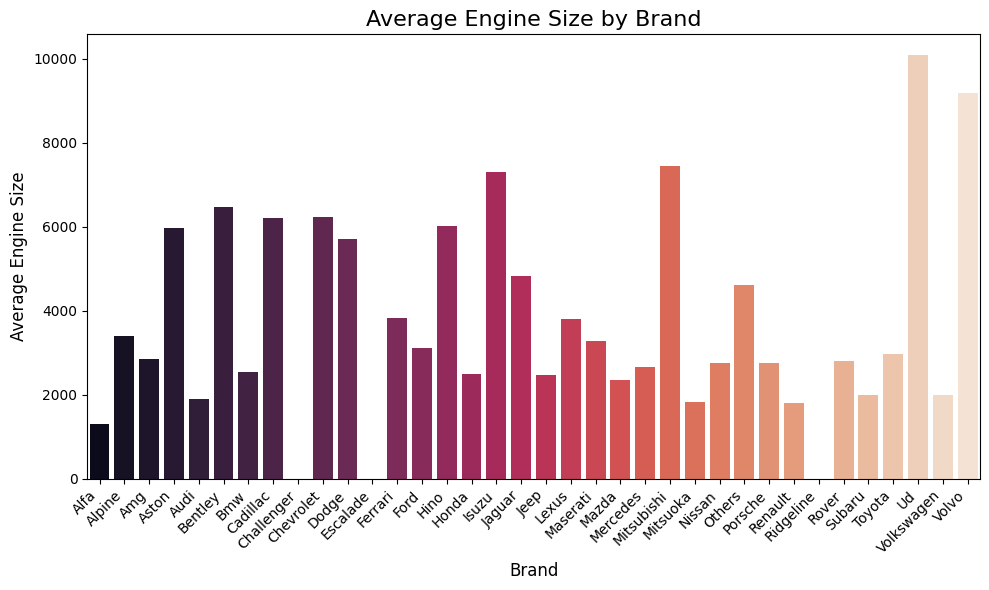

In [ ]:
# prompt: # prompt: Brand and Model Insights
# # Top 5 most common brands in the dataset.
# # Price ranges for the top brands.
# # Average mileage for vehicles by  top 10 brand.
# # Average engine size by brand.
# # Most popular models within a brand  also print charts of all

# Top 5 most common brands
top_5_brands = data_no_duplicates['Brand'].value_counts().nlargest(5)
print("Top 5 Most Common Brands:\n", top_5_brands)

# Price ranges for top brands
for brand in top_5_brands.index:
    brand_prices = data_no_duplicates[data_no_duplicates['Brand'] == brand]['price']
    print(f"\nPrice range for {brand}: ${brand_prices.min()} - ${brand_prices.max()}")

# Average mileage for vehicles by top 10 brands
top_10_brands = data_no_duplicates['Brand'].value_counts().nlargest(10)
avg_mileage_by_brand = data_no_duplicates.groupby('Brand')['mileage'].mean().loc[top_10_brands.index]
print("\nAverage Mileage for Top 10 Brands:\n", avg_mileage_by_brand)

# Average engine size by brand
avg_engine_by_brand = data_no_duplicates.groupby('Brand')['engine'].mean()
print("\nAverage Engine Size by Brand:\n", avg_engine_by_brand)

# Most popular models within each of the top 5 brands
for brand in top_5_brands.index:
    top_models = data_no_duplicates[data_no_duplicates['Brand'] == brand]['model_code'].value_counts().nlargest(5)
    print(f"\nTop 5 Models for {brand}:\n{top_models}")


# Plotting the top 5 brands
plt.figure(figsize=(10, 6))
sns.countplot(y='Brand', data=data_no_duplicates, order=top_5_brands.index, palette="viridis")
plt.title('Top 5 Most Common Brands', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.show()

# Plotting price ranges
plt.figure(figsize=(12, 6))
for brand in top_5_brands.index:
    sns.kdeplot(data_no_duplicates[data_no_duplicates['Brand'] == brand]['price'], label=brand, shade=True)
plt.title('Price Distribution for Top 5 Brands', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting average mileage
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_mileage_by_brand.index, y=avg_mileage_by_brand.values, palette="magma")
plt.title('Average Mileage for Top 10 Brands', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Average Mileage', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting average engine size
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_engine_by_brand.index, y=avg_engine_by_brand.values, palette='rocket')
plt.title('Average Engine Size by Brand', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Average Engine Size', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
data_no_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2598 entries, 0 to 2828
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   stock_id      2598 non-null   object  
 1   model_code    2598 non-null   category
 2   Title         2598 non-null   category
 3   Brand         2598 non-null   category
 4   Year          2598 non-null   float64 
 5   engine        2598 non-null   float64 
 6   fuel          2598 non-null   category
 7   transmission  2598 non-null   category
 8   body_type     2598 non-null   object  
 9   mileage       2598 non-null   int64   
 10  color         2598 non-null   category
 11  steering      2598 non-null   category
 12  drive_type    2598 non-null   object  
 13  seats         2598 non-null   float64 
 14  doors         2598 non-null   float64 
 15  price         2598 non-null   int64   
 16  location      2598 non-null   category
 17  age           2598 non-null   float64 
 18  YearGroup    

In [ ]:
# prompt: in body type where sports car  change it into sportscars

# Replace 'SPORTS' with 'SPORTS CARS' in the 'body_type' column
data['body_type'] = data['body_type'].replace('SPORTSCAR', 'SPORTS CARS')

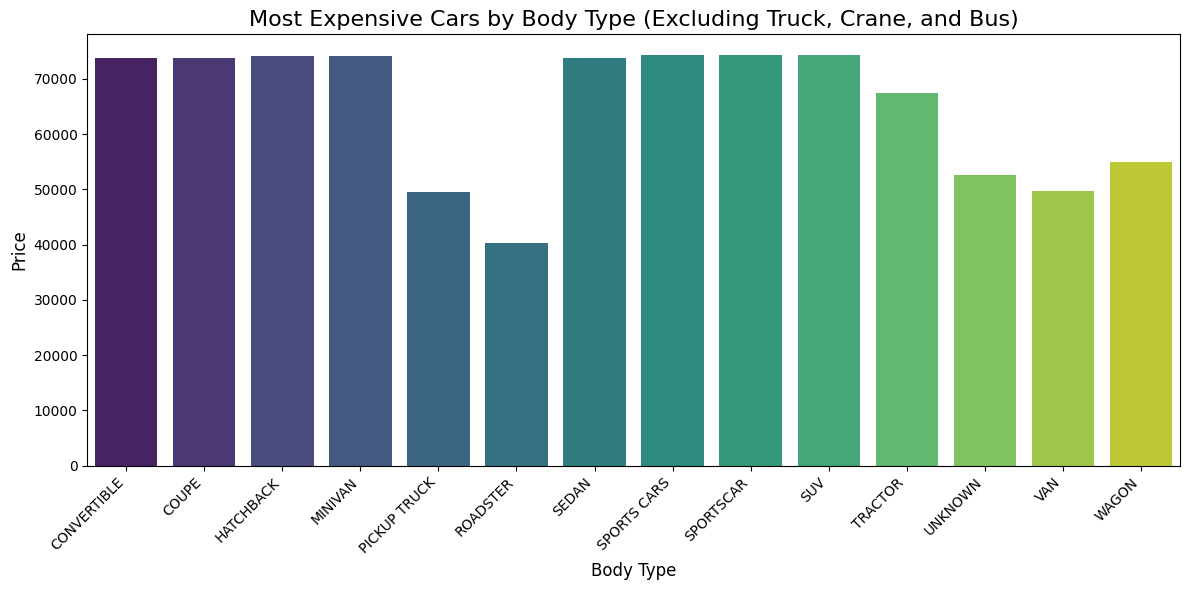

In [ ]:


# Filter out unwanted body types
filtered_data = data_no_duplicates[~data_no_duplicates['body_type'].isin(['TRUCK', 'CRANE', 'BUS'])]

# Find the most expensive cars for each body type
most_expensive_by_type = filtered_data.loc[filtered_data.groupby('body_type')['price'].idxmax()]

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='body_type', y='price', data=most_expensive_by_type, palette='viridis')
plt.title('Most Expensive Cars by Body Type (Excluding Truck, Crane, and Bus)', fontsize=16)
plt.xlabel('Body Type', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Number of vehicles per location (Top 5):
 location
Saitama    283
Tokyo      245
Aichi      234
Chiba      234
Osaka      186
Name: count, dtype: int64


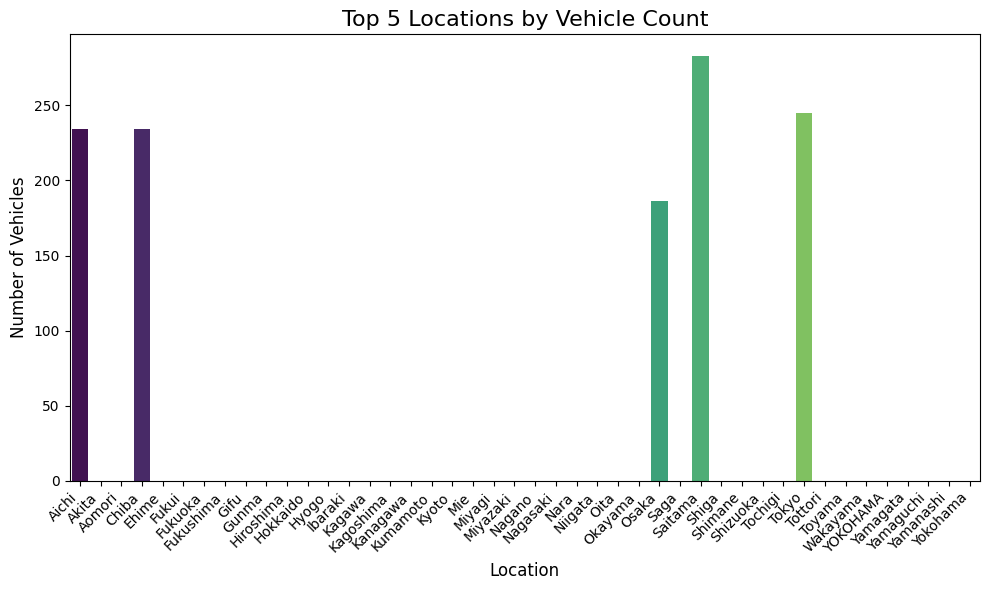

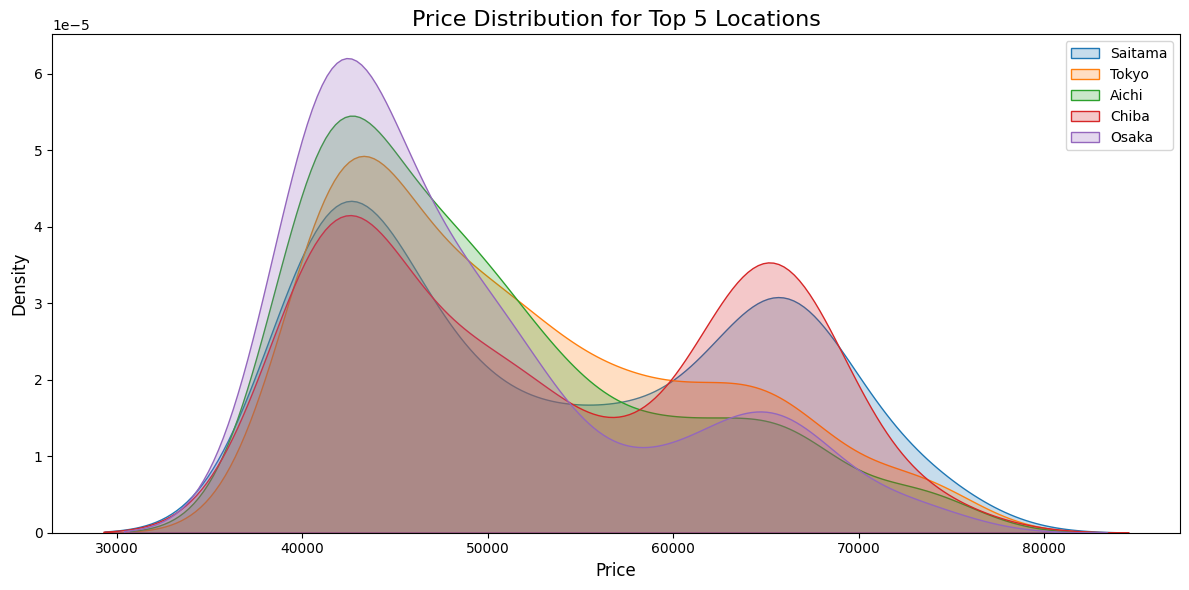


Average Mileage for Top 5 Locations:
 location
Saitama    42399.784452
Tokyo      27382.677551
Aichi      75316.623932
Chiba      79828.615385
Osaka      17384.607527
Name: mileage, dtype: float64


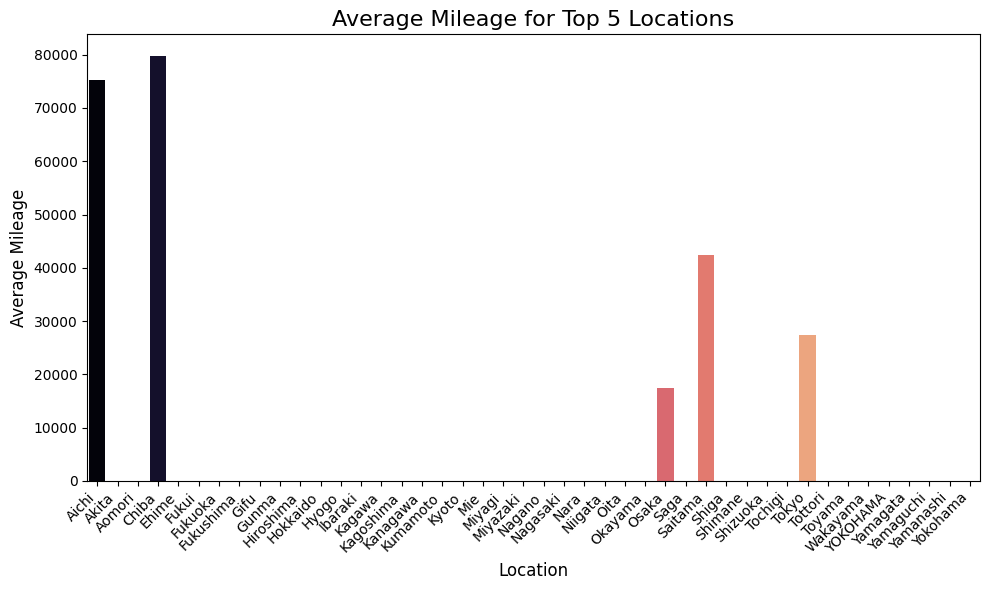


Top 5 Brands in Saitama:
Brand
Mitsubishi    95
Toyota        33
Hino          30
Bmw           22
Lexus         21
Name: count, dtype: int64


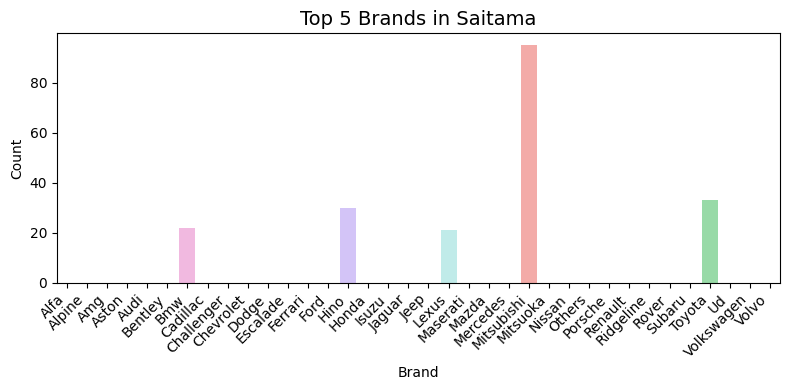


Top 5 Brands in Tokyo:
Brand
Toyota      67
Lexus       31
Audi        23
Bmw         22
Mercedes    16
Name: count, dtype: int64


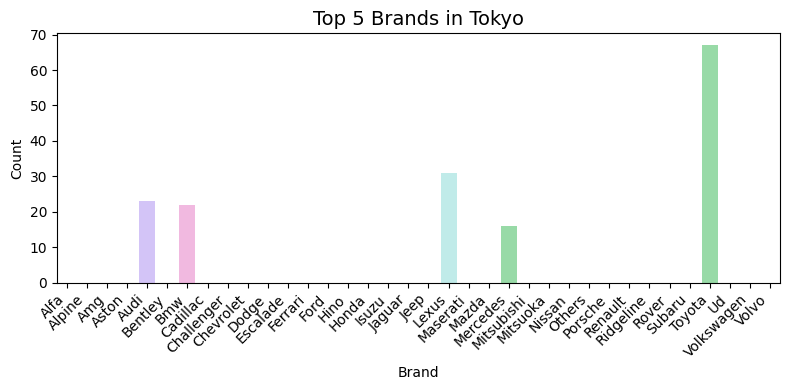


Top 5 Brands in Aichi:
Brand
Hino          37
Toyota        34
Mercedes      31
Mitsubishi    26
Porsche       19
Name: count, dtype: int64


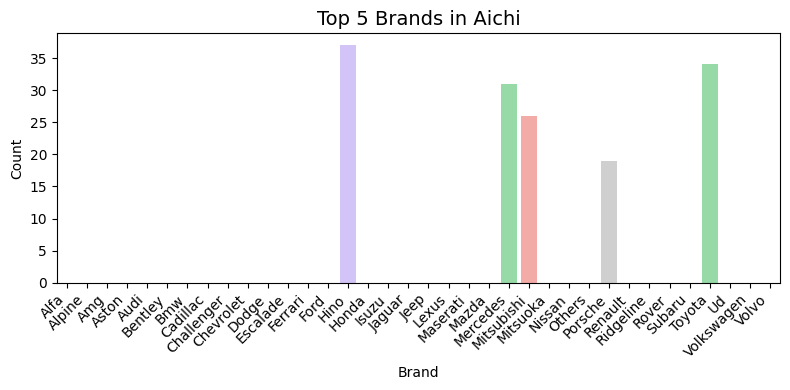


Top 5 Brands in Chiba:
Brand
Mitsubishi    80
Bmw           59
Hino          43
Isuzu         22
Mercedes      10
Name: count, dtype: int64


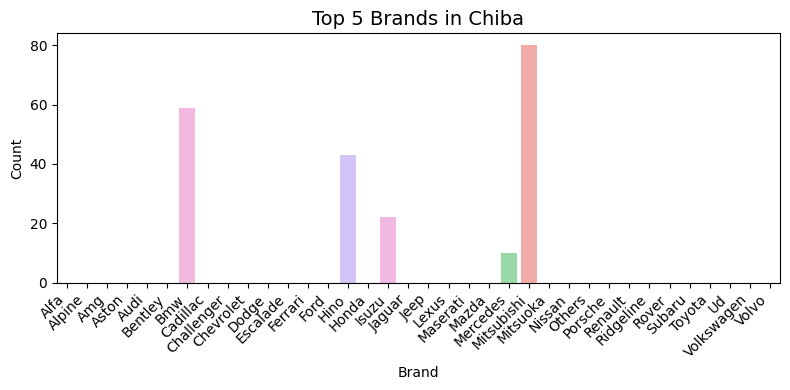


Top 5 Brands in Osaka:
Brand
Bmw         43
Audi        27
Jeep        20
Mercedes    19
Porsche     14
Name: count, dtype: int64


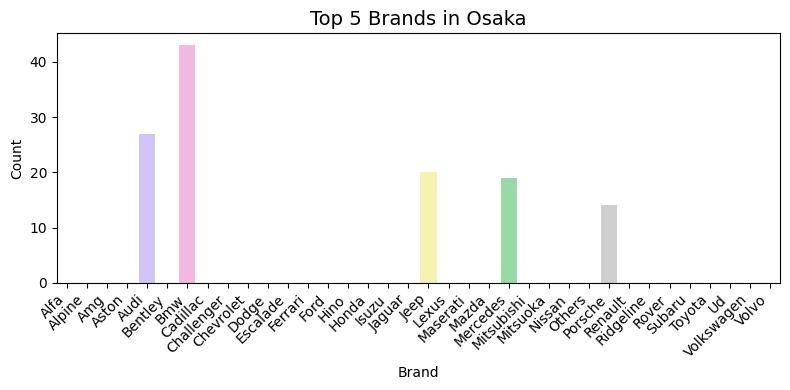

In [ ]:
# prompt: prompt: Location and Stock Insights
# # Number of vehicles available per location.
# # Price differences across locations.
# # Average mileage of vehicles by location.
# # Vehicle features unique to specific locations.
# # Top-selling vehicle brands by location.  dont print all locations  just only top 5 and make plots

# Assuming data_no_duplicates is already defined and processed as in your code.

# Number of vehicles available per location (Top 5 locations)
location_counts = data_no_duplicates['location'].value_counts().nlargest(5)
print("Number of vehicles per location (Top 5):\n", location_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=location_counts.index, y=location_counts.values, palette="viridis")
plt.title('Top 5 Locations by Vehicle Count', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Number of Vehicles', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Price differences across locations (Top 5 locations)
plt.figure(figsize=(12, 6))
for location in location_counts.index:
    sns.kdeplot(data_no_duplicates[data_no_duplicates['location'] == location]['price'], label=location, shade=True)
plt.title('Price Distribution for Top 5 Locations', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


# Average mileage of vehicles by location (Top 5 locations)
avg_mileage_by_location = data_no_duplicates.groupby('location')['mileage'].mean().loc[location_counts.index]
print("\nAverage Mileage for Top 5 Locations:\n", avg_mileage_by_location)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_mileage_by_location.index, y=avg_mileage_by_location.values, palette="magma")
plt.title('Average Mileage for Top 5 Locations', fontsize=16)
plt.xlabel('Location', fontsize=12)
plt.ylabel('Average Mileage', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Top-selling vehicle brands by location (Top 5 locations)
for location in location_counts.index:
    top_brands = data_no_duplicates[data_no_duplicates['location'] == location]['Brand'].value_counts().nlargest(5)
    print(f"\nTop 5 Brands in {location}:\n{top_brands}")

    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_brands.index, y=top_brands.values, palette='pastel')
    plt.title(f'Top 5 Brands in {location}', fontsize=14)
    plt.xlabel('Brand', fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

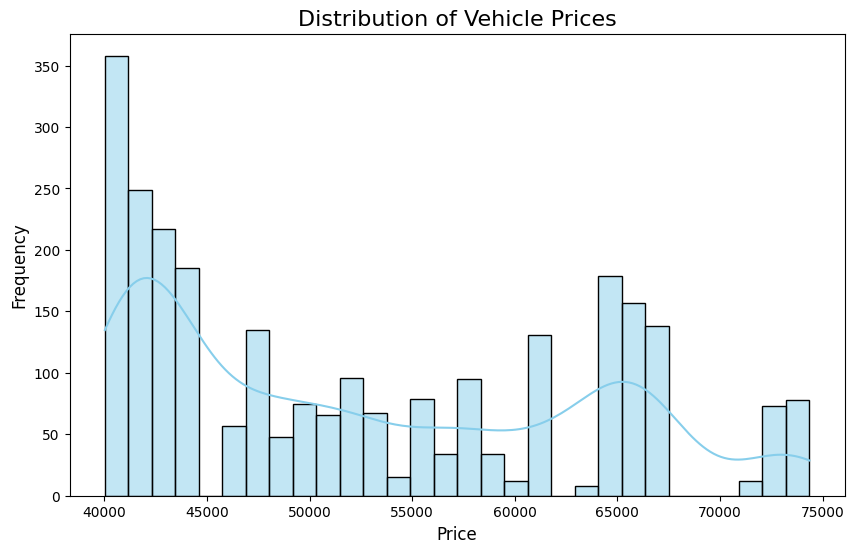

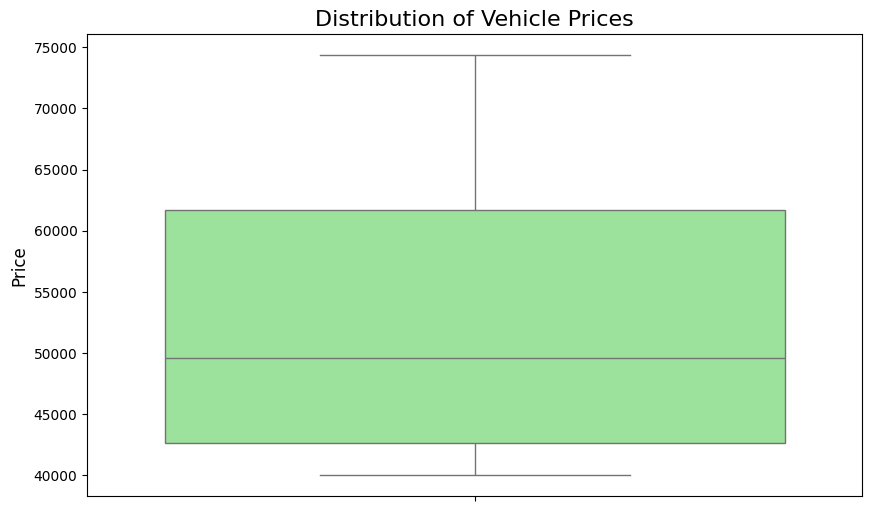

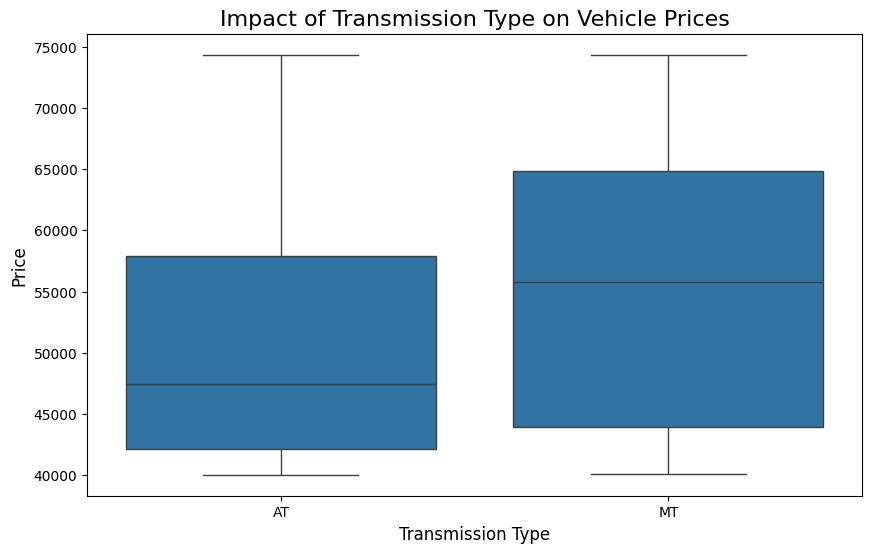

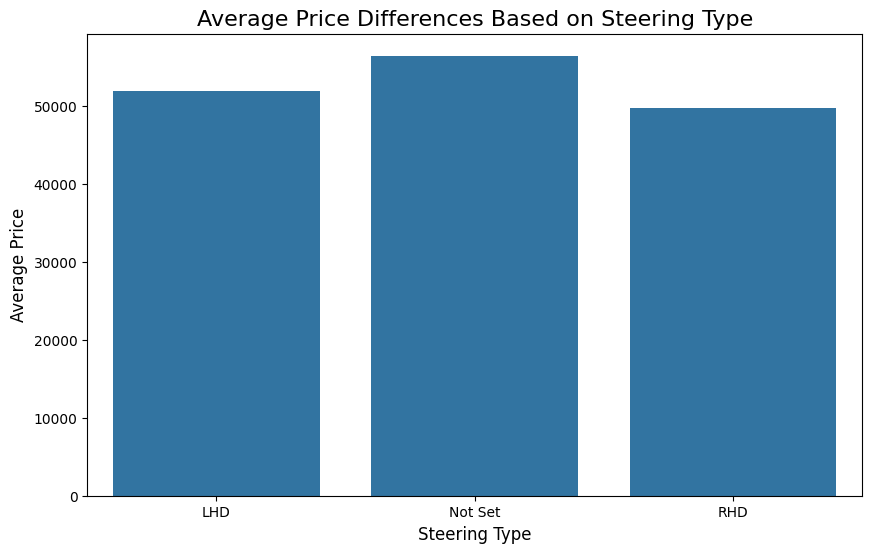

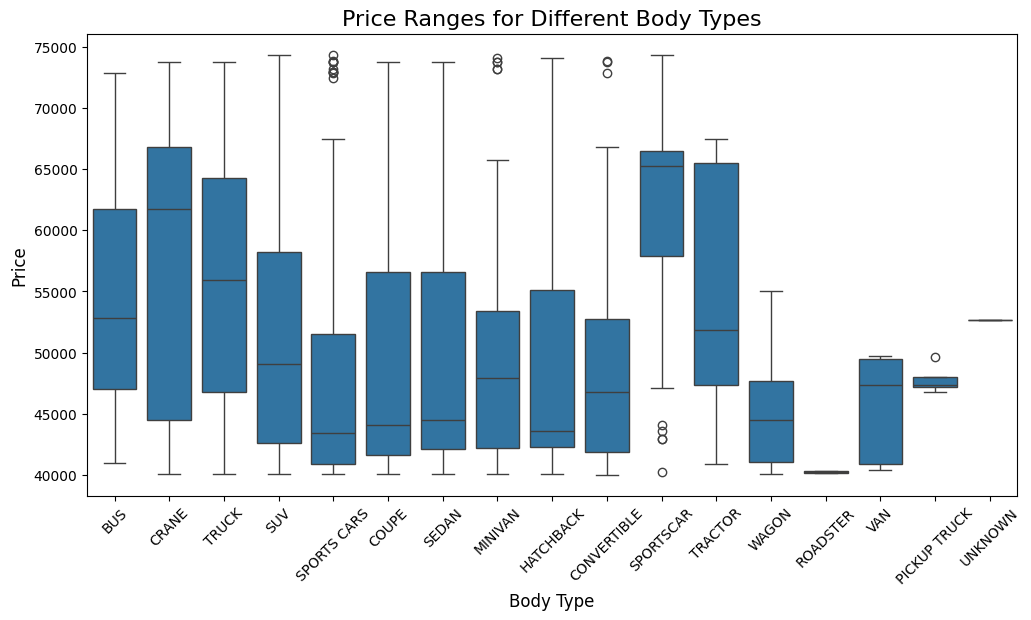

Vehicle with the highest price:
 stock_id         sat-16311033
model_code             E-FD3S
Title           Rx-7 Type R ?
Brand                   Mazda
Year                   1993.0
engine                 1400.0
fuel                   Petrol
transmission               MT
body_type         SPORTS CARS
mileage                 35033
color                  Silver
steering              Not Set
drive_type                2WD
seats                     4.0
doors                     4.0
price                   74360
location              Okayama
age                      31.0
YearGroup        [1993, 2003)
Name: 2733, dtype: object

Vehicle with the lowest price:
 stock_id                   sat-29422371
model_code                    ABA-982H1
Title            718 Boxster Base Grade
Brand                           Porsche
Year                             2016.0
engine                           2000.0
fuel                             Petrol
transmission                         AT
body_type         

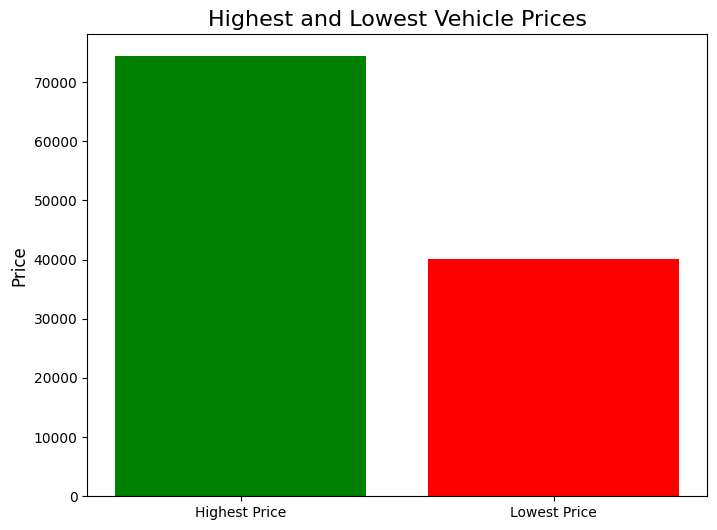

In [ ]:
# prompt: Price Insights
# Distribution of vehicle prices (e.g., histogram or boxplot).
# Impact of transmission type on vehicle prices.
# Average price differences based on steering type.
# Analysis of price ranges for different body types.
# Vehicles with the highest and lowest prices in the dataset. also plot this

# Assuming data_no_duplicates is already defined and processed as in your code.

# Distribution of vehicle prices (histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data_no_duplicates['price'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Vehicle Prices', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Distribution of vehicle prices (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(y=data_no_duplicates['price'], color='lightgreen')
plt.title('Distribution of Vehicle Prices', fontsize=16)
plt.ylabel('Price', fontsize=12)
plt.show()


# Impact of transmission type on vehicle prices
plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission', y='price', data=data_no_duplicates)
plt.title('Impact of Transmission Type on Vehicle Prices', fontsize=16)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.show()

# Average price differences based on steering type
plt.figure(figsize=(10, 6))
sns.barplot(x='steering', y='price', data=data_no_duplicates, estimator=np.mean, ci=None)  # ci=None removes confidence intervals
plt.title('Average Price Differences Based on Steering Type', fontsize=16)
plt.xlabel('Steering Type', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.show()

# Analysis of price ranges for different body types
plt.figure(figsize=(12, 6))
sns.boxplot(x='body_type', y='price', data=data_no_duplicates)
plt.title('Price Ranges for Different Body Types', fontsize=16)
plt.xlabel('Body Type', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Vehicles with the highest and lowest prices
highest_price_vehicle = data_no_duplicates.loc[data_no_duplicates['price'].idxmax()]
lowest_price_vehicle = data_no_duplicates.loc[data_no_duplicates['price'].idxmin()]

print("Vehicle with the highest price:\n", highest_price_vehicle)
print("\nVehicle with the lowest price:\n", lowest_price_vehicle)

#Plot Highest and Lowest Price Vehicles
plt.figure(figsize=(8, 6))
plt.bar(['Highest Price', 'Lowest Price'], [highest_price_vehicle['price'], lowest_price_vehicle['price']], color=['green', 'red'])
plt.title('Highest and Lowest Vehicle Prices', fontsize=16)
plt.ylabel('Price', fontsize=12)
plt.show()

Most common vehicle colors:
 color
Pearl        458
White        449
Black        445
Grey         411
Blue         397
Silver       391
Others        40
Red            3
Dark blue      1
Brown          1
Green          1
Purple         1
Name: count, dtype: int64


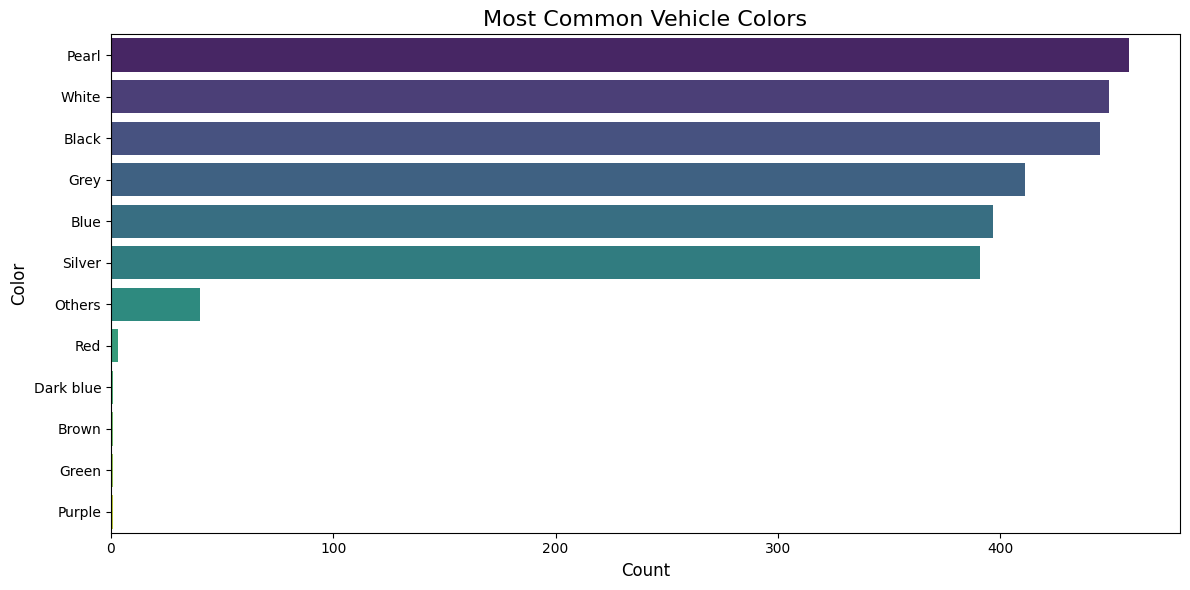


Average price differences for vehicles of different colors:
 color
Purple       64240.000000
Others       54595.275000
Blue         52904.062972
Black        52646.777528
Pearl        52646.010917
White        52479.171492
Grey         52191.776156
Red          52076.333333
Silver       51816.552430
Dark blue    51524.000000
Brown        42206.000000
Green        41516.000000
Name: price, dtype: float64


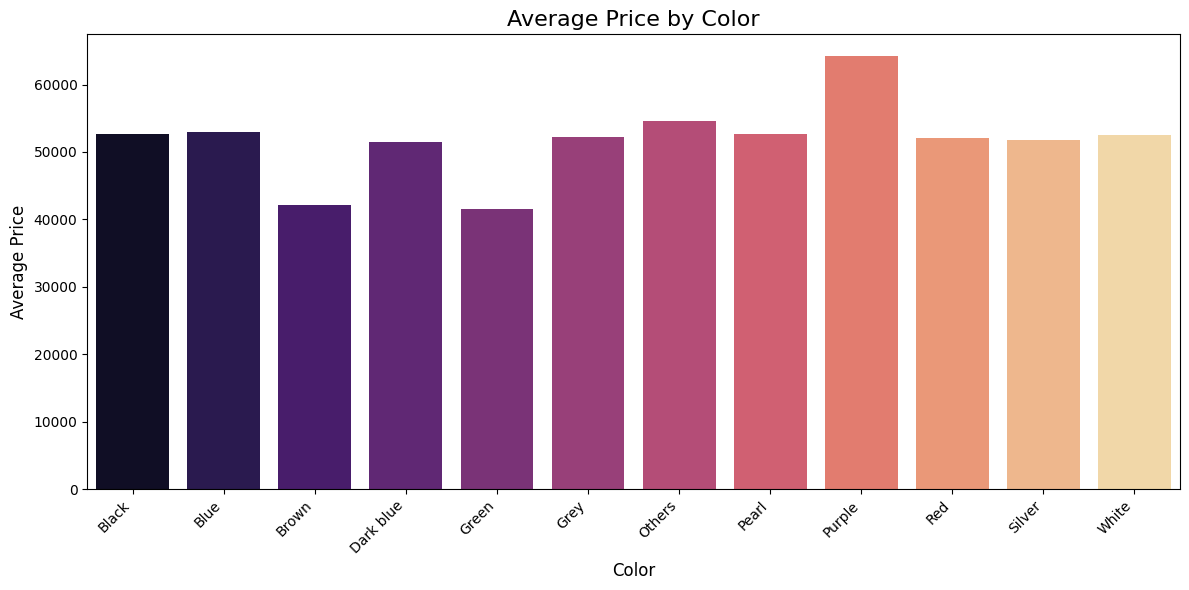


Top 5 Color Preferences in Saitama:
color
Silver    56
Blue      53
Black     48
Grey      44
White     44
Name: count, dtype: int64


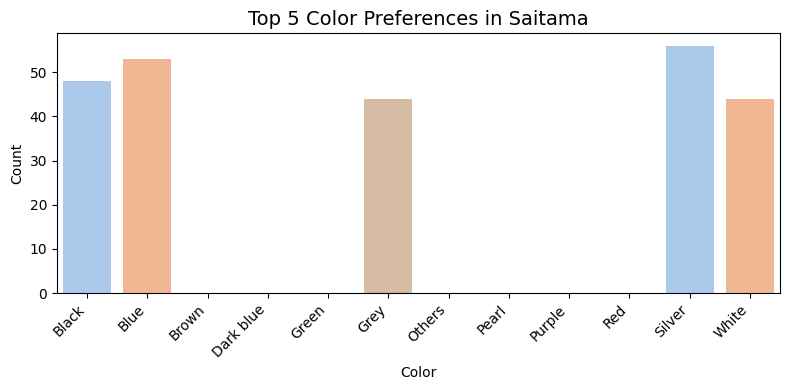


Top 5 Color Preferences in Tokyo:
color
Blue     44
Pearl    43
Grey     42
Black    42
White    41
Name: count, dtype: int64


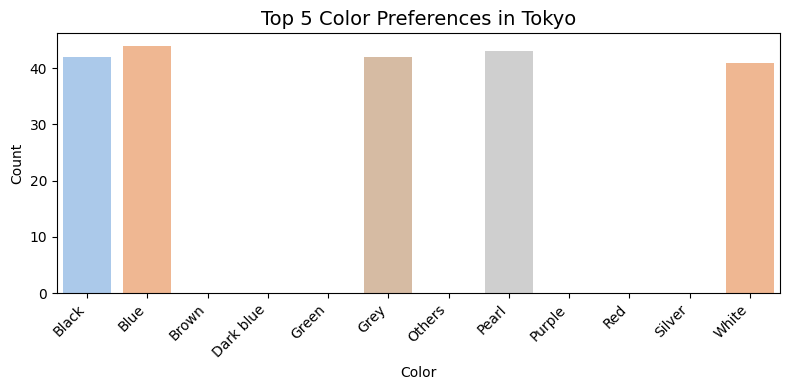


Top 5 Color Preferences in Aichi:
color
Pearl     46
Black     40
White     38
Blue      36
Silver    35
Name: count, dtype: int64


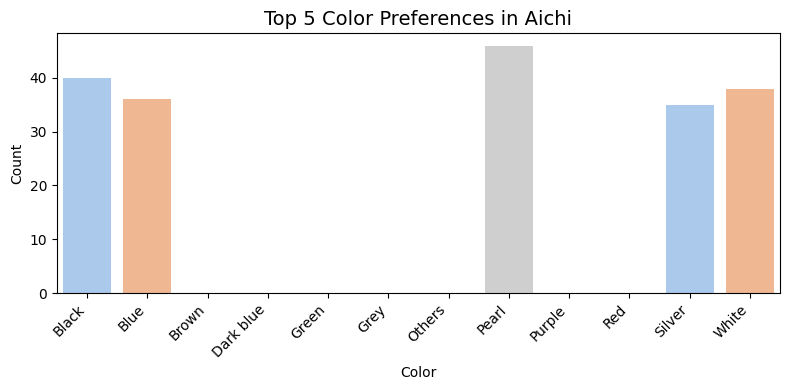


Top 5 Color Preferences in Chiba:
color
Pearl     49
White     47
Black     37
Grey      35
Silver    32
Name: count, dtype: int64


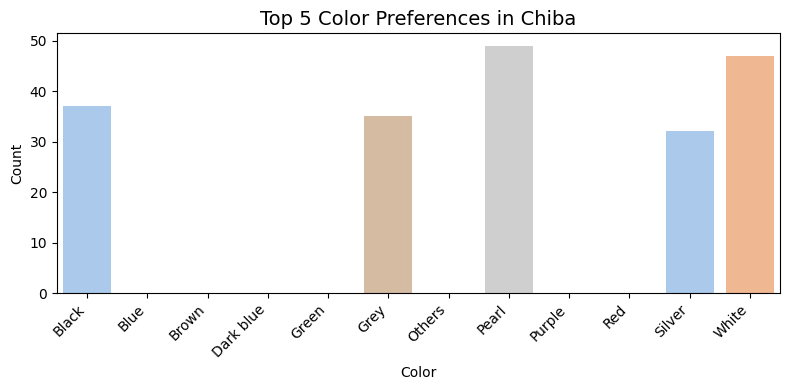


Top 5 Color Preferences in Osaka:
color
White    41
Pearl    38
Black    31
Blue     27
Grey     26
Name: count, dtype: int64


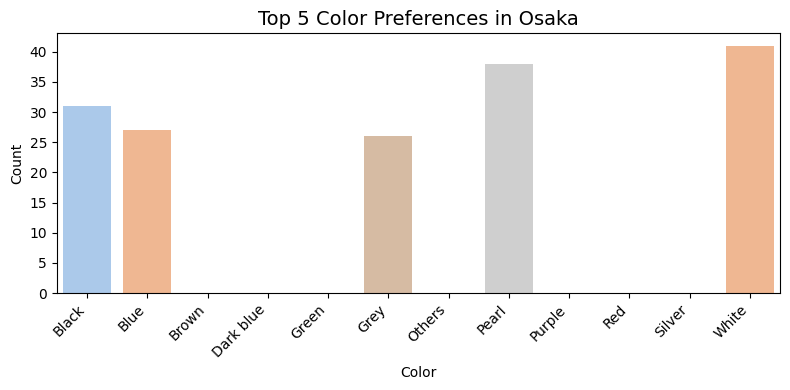

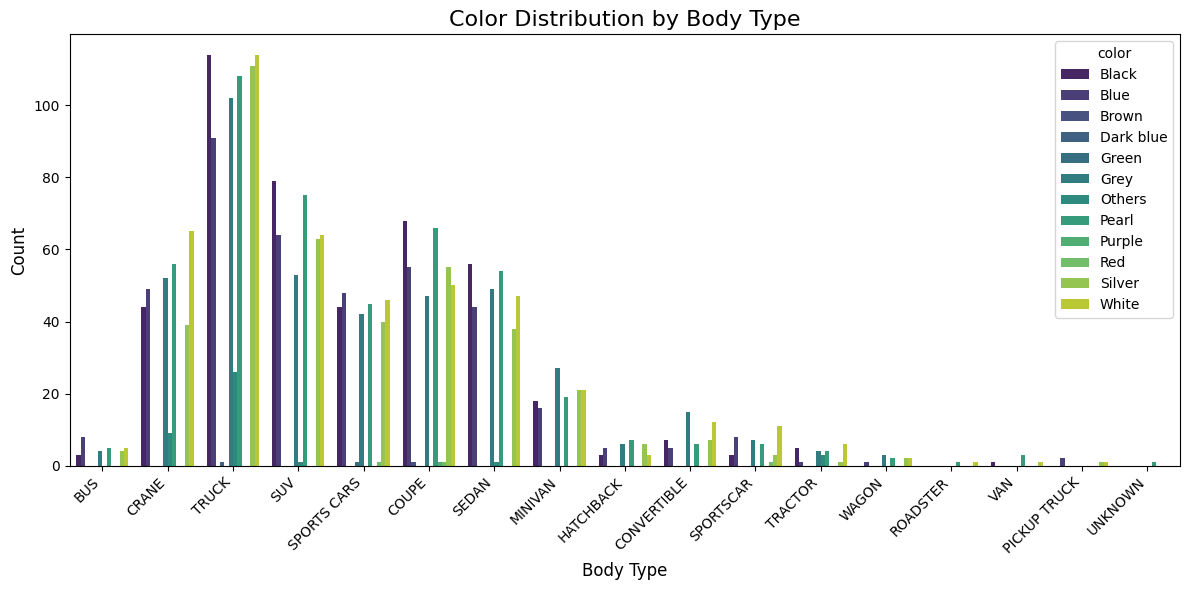

In [ ]:

# Most common vehicle colors
color_counts = data_no_duplicates['color'].value_counts()
print("Most common vehicle colors:\n", color_counts)

plt.figure(figsize=(12, 6))
sns.countplot(y='color', data=data_no_duplicates, order=color_counts.index, palette='viridis')
plt.title('Most Common Vehicle Colors', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Color', fontsize=12)
plt.tight_layout()
plt.show()

# Average price differences for vehicles of different colors
avg_price_by_color = data_no_duplicates.groupby('color')['price'].mean().sort_values(ascending=False)
print("\nAverage price differences for vehicles of different colors:\n", avg_price_by_color)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_by_color.index, y=avg_price_by_color.values, palette='magma')
plt.title('Average Price by Color', fontsize=16)
plt.xlabel('Color', fontsize=12)
plt.ylabel('Average Price', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Color preferences across different locations (Top 5 locations)
for location in location_counts.index:
    color_preferences = data_no_duplicates[data_no_duplicates['location'] == location]['color'].value_counts().nlargest(5)
    print(f"\nTop 5 Color Preferences in {location}:\n{color_preferences}")

    plt.figure(figsize=(8, 4))
    sns.barplot(x=color_preferences.index, y=color_preferences.values, palette='pastel')
    plt.title(f'Top 5 Color Preferences in {location}', fontsize=14)
    plt.xlabel('Color', fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Color distribution by body type
plt.figure(figsize=(12, 6))
sns.countplot(x='body_type', hue='color', data=data_no_duplicates, palette='viridis')
plt.title('Color Distribution by Body Type', fontsize=16)
plt.xlabel('Body Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Average seats by body type:
 body_type
BUS             36.241379
CONVERTIBLE      4.211538
COUPE            4.078488
CRANE            2.261146
HATCHBACK        4.666667
MINIVAN          6.631148
PICKUP TRUCK     4.750000
ROADSTER         2.000000
SEDAN            4.809689
SPORTS CARS      4.614232
SPORTSCAR        4.538462
SUV              5.360902
TRACTOR          2.000000
TRUCK            2.301349
UNKNOWN          4.000000
VAN              6.600000
WAGON            5.000000
Name: seats, dtype: float64


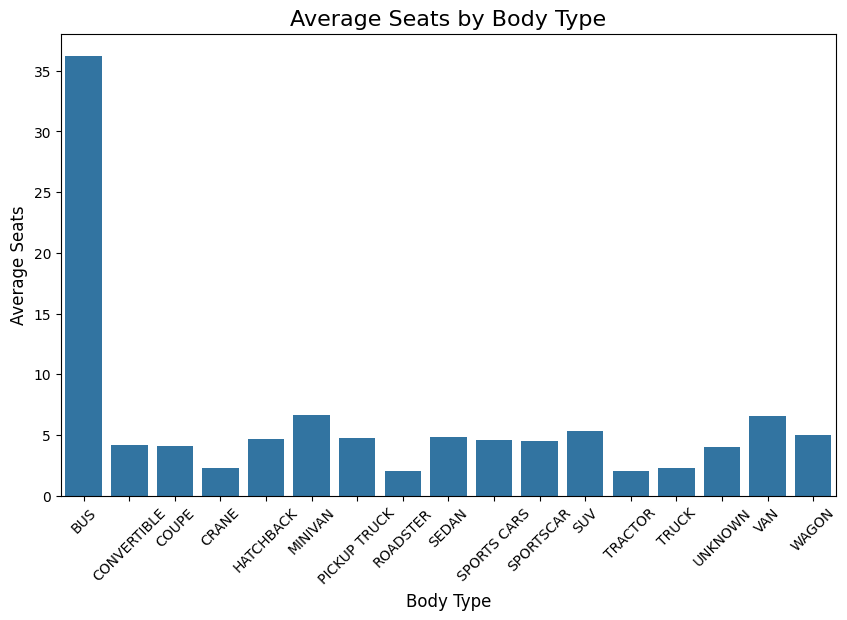

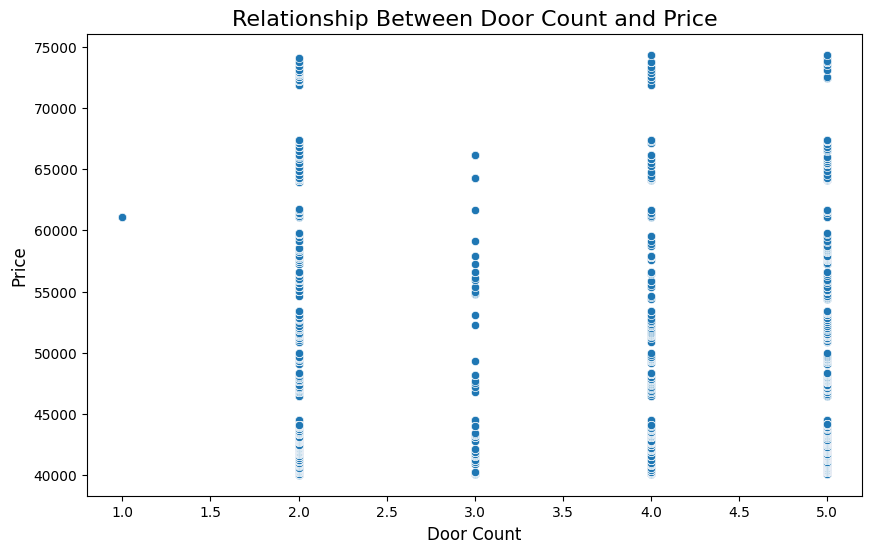

Correlation between door count and price: -0.20283207021714253


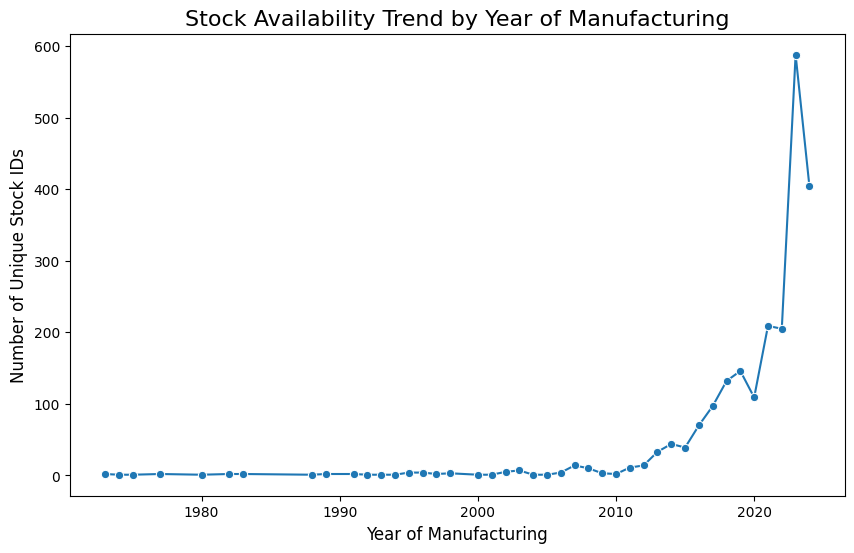

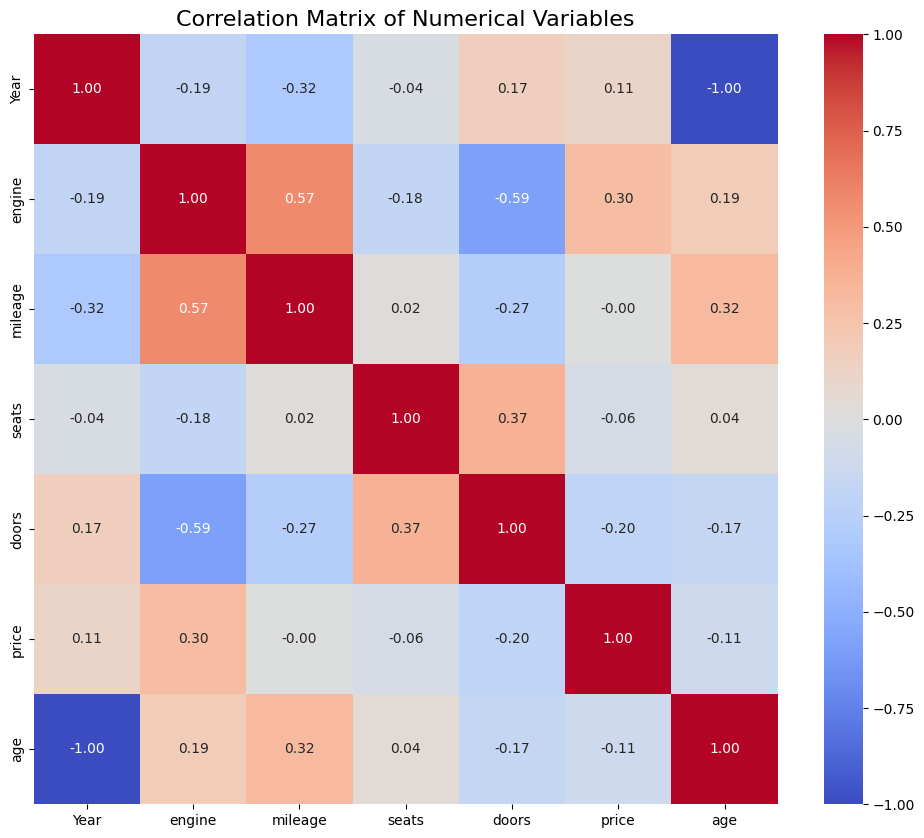

Correlation Matrix:
              Year    engine   mileage     seats     doors     price       age
Year     1.000000 -0.191947 -0.316524 -0.041533  0.167805  0.113225 -1.000000
engine  -0.191947  1.000000  0.572641 -0.183798 -0.589099  0.304407  0.191947
mileage -0.316524  0.572641  1.000000  0.023309 -0.269434 -0.004796  0.316524
seats   -0.041533 -0.183798  0.023309  1.000000  0.370785 -0.061558  0.041533
doors    0.167805 -0.589099 -0.269434  0.370785  1.000000 -0.202832 -0.167805
price    0.113225  0.304407 -0.004796 -0.061558 -0.202832  1.000000 -0.113225
age     -1.000000  0.191947  0.316524  0.041533 -0.167805 -0.113225  1.000000


In [ ]:
# prompt: # prompt: Average seats in vehicles grouped by body type.
# # Relationship between door count and price.
# # Trends in stock availability by year of manufacturing.
# # Correlation analysis across all numerical variables (e.g., mileage, engine, price

# Assuming data_no_duplicates is already defined and processed

# 1. Average seats in vehicles grouped by body type
average_seats_by_body_type = data_no_duplicates.groupby('body_type')['seats'].mean()
print("Average seats by body type:\n", average_seats_by_body_type)

plt.figure(figsize=(10, 6))
sns.barplot(x=average_seats_by_body_type.index, y=average_seats_by_body_type.values)
plt.title('Average Seats by Body Type', fontsize=16)
plt.xlabel('Body Type', fontsize=12)
plt.ylabel('Average Seats', fontsize=12)
plt.xticks(rotation=45)
plt.show()


# 2. Relationship between door count and price
plt.figure(figsize=(10, 6))
sns.scatterplot(x='doors', y='price', data=data_no_duplicates)
plt.title('Relationship Between Door Count and Price', fontsize=16)
plt.xlabel('Door Count', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.show()

# Calculate correlation
correlation = data_no_duplicates['doors'].corr(data_no_duplicates['price'])
print(f"Correlation between door count and price: {correlation}")


# 3. Trends in stock availability by year of manufacturing
# Assuming 'stock_availability' is a binary or numerical column indicating stock availability
# If it's a binary column (e.g. 0 or 1), sum it
# Assuming 'stock_id' can be used as a proxy for stock availability
# We count the unique 'stock_id' values for each year

stock_by_year = data_no_duplicates.groupby('Year')['stock_id'].nunique().reset_index()
stock_by_year.rename(columns={'stock_id': 'stock_count'}, inplace=True)  # Rename for clarity

plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='stock_count', data=stock_by_year, marker='o')
plt.title('Stock Availability Trend by Year of Manufacturing', fontsize=16)
plt.xlabel('Year of Manufacturing', fontsize=12)
plt.ylabel('Number of Unique Stock IDs', fontsize=12) # Updated y-axis label
plt.show()

# 4. Correlation analysis across all numerical variables
numerical_cols = data_no_duplicates.select_dtypes(include=np.number).columns
correlation_matrix = data_no_duplicates[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables', fontsize=16)
plt.show()

print("Correlation Matrix:\n", correlation_matrix)

In [ ]:
# prompt: remove outliars in price distribution

# Calculate IQR for 'price'
Q1 = data_no_duplicates['price'].quantile(0.25)
Q3 = data_no_duplicates['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
data_no_outliers = data_no_duplicates[
    (data_no_duplicates['price'] >= lower_bound) & (data_no_duplicates['price'] <= upper_bound)
]
data_no_outliers.shape
# Now data_no_outliers contains the DataFrame without price outliers

(2598, 19)

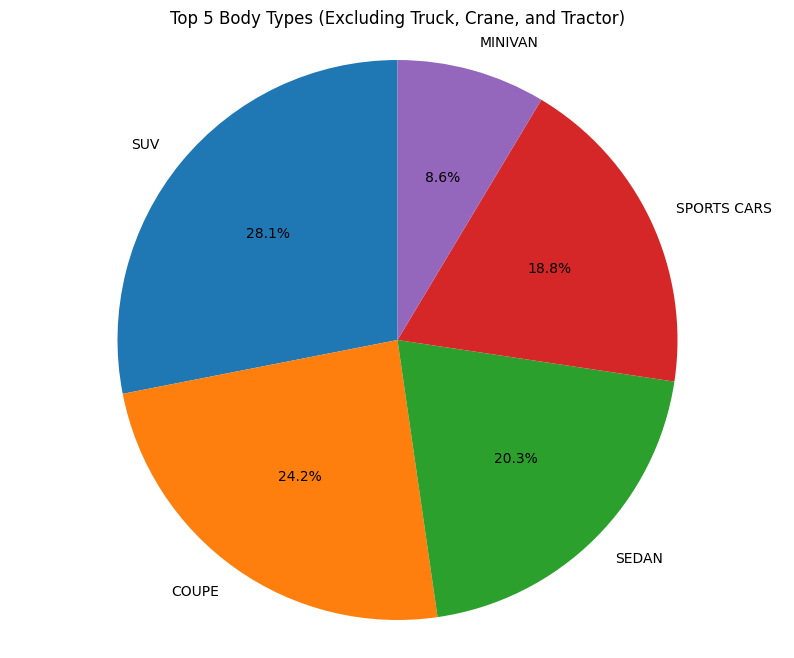

In [ ]:

filtered_body_types = data_no_duplicates[~data_no_duplicates['body_type'].isin(['TRUCK', 'CRANE', 'TRACTOR'])]
body_type_counts = filtered_body_types['body_type'].value_counts()

# Get the top 5 body types
top_5_body_types = body_type_counts.nlargest(5)

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(top_5_body_types, labels=top_5_body_types.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Body Types (Excluding Truck, Crane, and Tractor)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

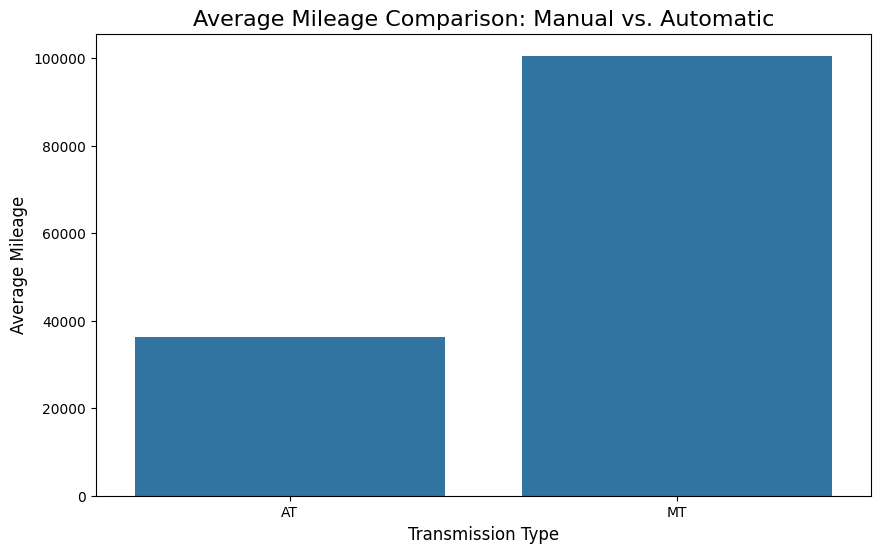

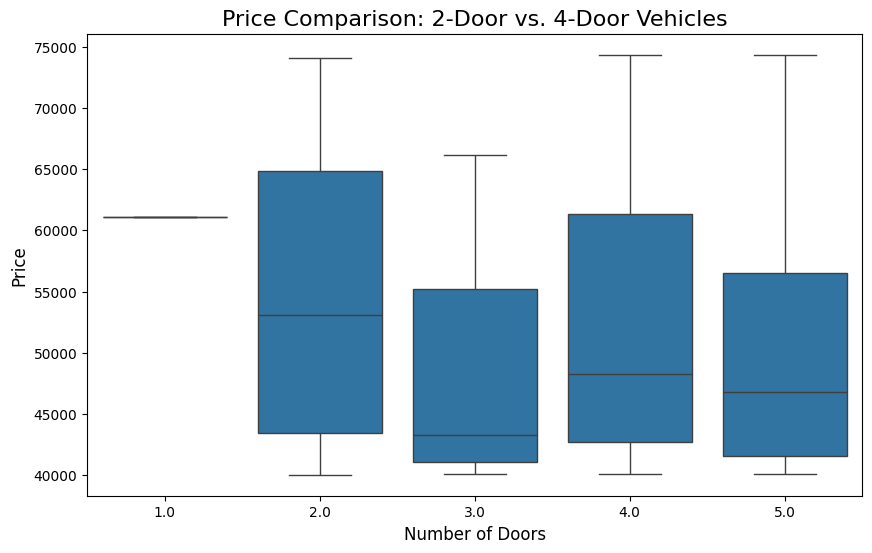

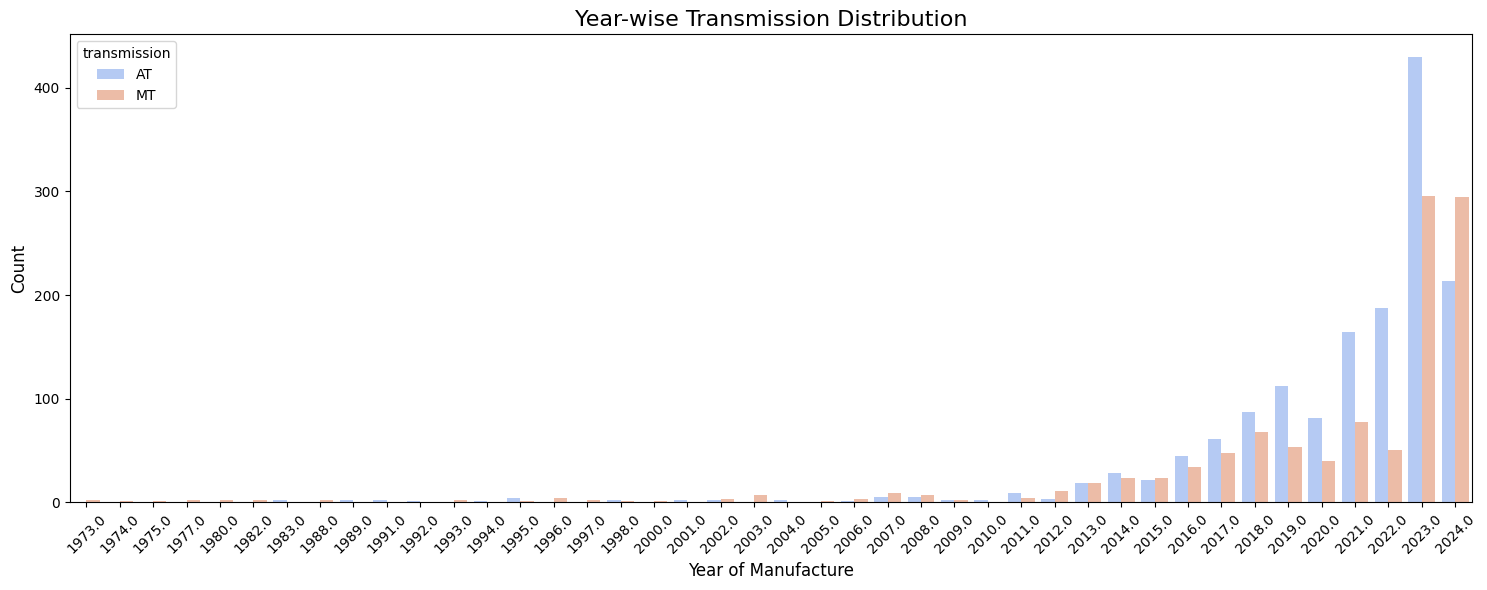

In [ ]:

plt.figure(figsize=(10, 6))
sns.barplot(x='transmission', y='mileage', data=data_no_duplicates, estimator=np.mean, ci=None)
plt.title('Average Mileage Comparison: Manual vs. Automatic', fontsize=16)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Average Mileage', fontsize=12)
plt.show()

# Price comparison between 2-door and 4-door vehicles.
plt.figure(figsize=(10, 6))
sns.boxplot(x='doors', y='price', data=data_no_duplicates)
plt.title('Price Comparison: 2-Door vs. 4-Door Vehicles', fontsize=16)
plt.xlabel('Number of Doors', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.show()




# Year-wise comparison of manual vs. automatic transmission distribution.
plt.figure(figsize=(15, 6))
sns.countplot(x='Year', hue='transmission', data=data_no_duplicates, palette="coolwarm")
plt.title('Year-wise Transmission Distribution', fontsize=16)
plt.xlabel('Year of Manufacture', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
data_no_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2598 entries, 0 to 2828
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   stock_id      2598 non-null   object  
 1   model_code    2598 non-null   category
 2   Title         2598 non-null   category
 3   Brand         2598 non-null   category
 4   Year          2598 non-null   float64 
 5   engine        2598 non-null   float64 
 6   fuel          2598 non-null   category
 7   transmission  2598 non-null   category
 8   body_type     2598 non-null   object  
 9   mileage       2598 non-null   int64   
 10  color         2598 non-null   category
 11  steering      2598 non-null   category
 12  drive_type    2598 non-null   object  
 13  seats         2598 non-null   float64 
 14  doors         2598 non-null   float64 
 15  price         2598 non-null   int64   
 16  location      2598 non-null   category
 17  age           2598 non-null   float64 
 18  YearGroup    

In [ ]:
import pandas as pd
from scipy.stats import zscore

# Make a copy of the original data to avoid changes to it
cleaned_data =data_no_duplicates.copy()

# List of numeric columns to clean
numeric_columns = ['price', 'mileage', 'engine', 'age', 'Year', 'seats', 'doors']

# Function to remove outliers using the Z-score method
def remove_outliers_zscore(data, column, z_threshold=3):
    """
    Removes outliers using the Z-score method for a specified column.
    Args:
    - data (DataFrame): The input DataFrame.
    - column (str): The column to check for outliers.
    - z_threshold (float): The Z-score threshold (default is 3).

    Returns:
    - DataFrame with outliers removed for the specified column.
    """
    z_scores = zscore(data[column])
    return data[(abs(z_scores) < z_threshold)]

# Apply Z-score method for each numeric column
for col in numeric_columns:
    if col in cleaned_data.columns:  # Ensure the column exists in the data
        cleaned_data = remove_outliers_zscore(cleaned_data, col)

# Display information about the cleaned data
print(cleaned_data.info())


<class 'pandas.core.frame.DataFrame'>
Index: 2346 entries, 1 to 2826
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   stock_id      2346 non-null   object  
 1   model_code    2346 non-null   category
 2   Title         2346 non-null   category
 3   Brand         2346 non-null   category
 4   Year          2346 non-null   float64 
 5   engine        2346 non-null   float64 
 6   fuel          2346 non-null   category
 7   transmission  2346 non-null   category
 8   body_type     2346 non-null   object  
 9   mileage       2346 non-null   int64   
 10  color         2346 non-null   category
 11  steering      2346 non-null   category
 12  drive_type    2346 non-null   object  
 13  seats         2346 non-null   float64 
 14  doors         2346 non-null   float64 
 15  price         2346 non-null   int64   
 16  location      2346 non-null   category
 17  age           2346 non-null   float64 
 18  YearGroup    

Original Data Shape: (2598, 19)
Cleaned Data Shape: (2346, 19)


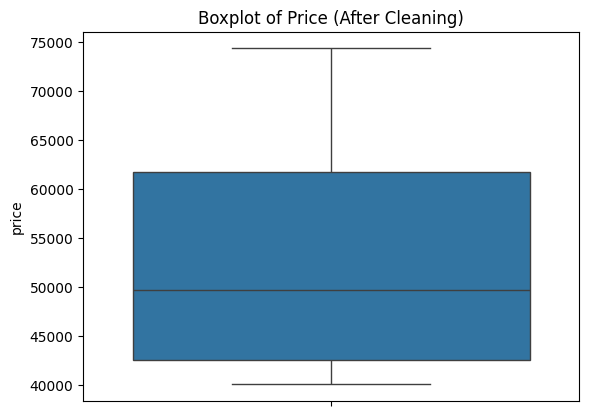

In [ ]:
# Compare the original and cleaned data shapes
print("Original Data Shape:", data_no_duplicates.shape)
print("Cleaned Data Shape:", cleaned_data.shape)

# Visualize distributions post-cleaning
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=cleaned_data['price'])
plt.title("Boxplot of Price (After Cleaning)")
plt.show()


In [ ]:
cleaned_data.columns

Index(['stock_id', 'model_code', 'Title', 'Brand', 'Year', 'engine', 'fuel',
       'transmission', 'body_type', 'mileage', 'color', 'steering',
       'drive_type', 'seats', 'doors', 'price', 'location', 'age',
       'YearGroup'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Step 1: Select features and target
features = ['Year', 'engine', 'mileage', 'age', 'seats', 'doors', 'Brand', 'fuel', 'transmission', 'location']
target = 'price'

# Ensure the dataset contains all selected features
data_subset = cleaned_data[features + [target]]

# Step 2: Split the dataset
X = data_subset.drop(target, axis=1)
y = data_subset[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Preprocessing pipeline
numeric_features = ['Year', 'engine', 'mileage', 'age', 'seats', 'doors']
categorical_features = ['Brand', 'fuel', 'transmission', 'location']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Step 4: Build the regression pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Step 5: Train the model
model.fit(X_train, y_train)

# Step 6: Evaluate the model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

# Save the model for future predictions (optional)
import joblib
joblib.dump(model, 'price_prediction_model.pkl')


Mean Absolute Error: 3417.82
Mean Squared Error: 26713857.56
R^2 Score: 0.77


['price_prediction_model.pkl']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Step 1: Select features and target
features = ['Year', 'engine', 'mileage', 'age', 'seats', 'doors', 'Brand', 'fuel', 'transmission', 'location', 'body_type']
target = 'price'

# Ensure the dataset contains all selected features
data_subset = cleaned_data[features + [target]]

# Step 2: Split the dataset
X = data_subset.drop(target, axis=1)
y = data_subset[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Preprocessing pipeline
numeric_features = ['Year', 'engine', 'mileage', 'age', 'seats', 'doors']
categorical_features = ['Brand', 'fuel', 'transmission', 'location', 'body_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Step 4: Build the regression pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Step 5: Train the model
model.fit(X_train, y_train)

# Step 6: Evaluate the model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

# Save the model for future predictions (optional)
import joblib
joblib.dump(model, 'price_prediction_model_with_body_type.pkl')


Mean Absolute Error: 3414.69
Mean Squared Error: 25640804.07
R^2 Score: 0.78


['price_prediction_model_with_body_type.pkl']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Step 1: Select features and target (removed 'doors' and 'seats')
features = ['Year', 'engine', 'mileage', 'age', 'Brand', 'fuel', 'transmission', 'location', 'body_type']
target = 'price'

# Ensure the dataset contains all selected features
data_subset = cleaned_data[features + [target]]

# Step 2: Split the dataset
X = data_subset.drop(target, axis=1)
y = data_subset[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Preprocessing pipeline
numeric_features = ['Year', 'engine', 'mileage', 'age']  # Removed 'seats' and 'doors'
categorical_features = ['Brand', 'fuel', 'transmission', 'location', 'body_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# Step 4: Build the regression pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Step 5: Train the model
model.fit(X_train, y_train)

# Step 6: Evaluate the model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")




Mean Absolute Error: 3629.66
Mean Squared Error: 28484731.35
R^2 Score: 0.76


In [ ]:
import pandas as pd
import random

# Assuming cleaned_data is your dataset
lottery_data = cleaned_data.copy()

# Step 1: Define the total probability and assign each car a probability
prob_per_car = 1 / 10000

# Step 2: Randomly select 5 cars for the menu
random_cars = lottery_data.sample(n=5, random_state=None)  # Removed fixed random_state for variability

# Display the menu of cars for selection
print("Select a car from the following options:")
for idx, row in random_cars.iterrows():
    print(f"{idx + 1}. {row['Title']}")

# Step 3: Get user input for car selection
try:
    user_choice = int(input("Enter the number of the car you want to select: "))
    if 1 <= user_choice <= 5:
        selected_car = random_cars.iloc[user_choice - 1]
        car_name = selected_car['Title']
        print(f"\nYou selected: {car_name}")

        # Step 4: Randomly choose a car from the entire dataset as the lottery car
        lottery_winner = lottery_data.sample(n=1, random_state=None)  # Removed fixed random_state for variability
        winning_car_name = lottery_winner['Title'].values[0]
        print(f"\nThe randomly selected winning car is: {winning_car_name}")

        # Step 5: Check if the user's selected car matches the randomly chosen car
        if car_name == winning_car_name:
            print(f"Congratulations! You won the {car_name}!")
        else:
            print(f"Sorry! The winning car was {winning_car_name}. Better luck next time!")

    else:
        print("Invalid selection! Please choose a number between 1 and 5.")
except ValueError:
    print("Invalid input! Please enter a valid number.")


Select a car from the following options:
992. 8 Series Gran Coupe 840i Exclusive M Sport
268. M3 Sedan Competition M Xdrive
1137. Forward Wing Truck
1858.  Defender 90
429. Q8 E-tron Sportback 55 Quattro S Line
